# Статистика, DS-поток
## Марафон-домашка SM.10, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.



**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 70 баллов;
* Задача 2 &mdash; 40 баллов;
* Задача 3 &mdash; 120 баллов;
* Задача 4 &mdash; 50 баллов;
* Задача 5 &mdash; 70 баллов.



In [ ]:
# Bot check

# HW_ID: ds_sm10
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [33]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm
from typing import Tuple, Union, Literal
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_percentage_error, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV

from catboost import CatBoostRegressor, CatBoostClassifier

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.nonparametric.kernel_regression import KernelReg

RANDOM_STATE = 42

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована

---
### Задача 1.

Рассмотрим АБ-тест на двух группах для изучения влияния изменения среды на целевую метрику.
* *Контрольная группа A:* использует *основную* версию системы. Обозначим значения целевой метрики как $Y_1 = (Y_{11}, ..., Y_{1n}), \mathsf{E} Y_{1i} = a$.
    
    
* *Исследуемая группа B:* использует *новую* версию системы. Обозначим значения целевой метрики как $Y_2 = (Y_{21}, ..., Y_{2m}), \mathsf{E} Y_{2i} = b$.
		


Рассмотрим случай, при котором неизвестная дисперсия выборок может быть разной: $\mathsf{D} Y_{1i} = \sigma_1^2, \mathsf{D} Y_{1i} = \sigma_2^2$. В задаче SB.9.2 мы получили доверительные интервалы для $b-a$ уровня доверия $1-\alpha$ и эквивалентные критерии для проверки $\mathsf{H}_0$, используя устойчивые оценки дисперсии с ковариационной матрицей типов HC0-HC3.

В частности, в случае HC2 мы использовали асимптотически нормальную статистику 
$$T(X, Y) = \frac{\overline{Y}_2 - \overline{Y}_1}{\sqrt{\left. S_1^2 \right/ (n-1) + \left. S_2^2 \right/ (m-1)}},$$
которую для выборок конечного размера приближали распределением $T_{n+m-2}$.

На практике широко используют T-критерий Уэлша, статистика которого имеет тот же вид, но для выборок конечного размера используется приближение распределением $T_{df}$, где
$$df = \left. \left(\frac{S_{1,несм}^2}{n} + \frac{S_{2,несм}^2}{m}\right)^2 \right/ \left(\frac{S_{1,несм}^4}{n^2(n-1)} + \frac{S_{2,несм}^4}{m^2(m-1)}\right).$$

В частности, его реализует функция `scipy.stats.ttest_ind(sample_a, sample_b, equal_var=False)`. Функция возвращает статистику критерия, p-value и величину $df$. Суффикс `ind` расшифровывается как *independent*, что означает требование независимости выборок.

В этой задаче мы сравним T-критерий Уэлша с критериями, которые мы получили в SB.9.2.

**1.** Исследуйте поведение числа степеней свободы для критерия Уэлша и сравните его с $n+m-2$, полученным ранее. Рассмотрите зависимость от следующих факторов.
* Размер выборки: постройте график по сетке размеров выборки.
* Различия дисперсии выборок.
* Тип распределения: исследуйте как нормальное, так и несимметричные распределения.

In [209]:
n = 200
m = 100
a = 5
b = 7
sigma1 = 3
sigma2 = 2

y1 = sps.norm(loc=a, scale=sigma1).rvs(n)
y2 = sps.norm(loc=b, scale=sigma2).rvs(m)

res = sps.ttest_ind(y1, y2)
print(f'Статистика: {res.statistic:.2f}\nP value: {res.pvalue:.2f}\nСтепени свободы: {res.df:.2f}')

Статистика: -7.01
P value: 0.00
Степени свободы: 298.00


In [214]:
a = 5
b = 7
sigma1 = 3
sigma2 = 2

n_grid = np.arange(1, 1001)
m = 100
df1 = n_grid + m - 2
df2 = np.zeros(len(n_grid))
for i, n in tqdm(enumerate(n_grid)):
    y1 = sps.norm(loc=a, scale=sigma1).rvs(n)
    y2 = sps.norm(loc=b, scale=sigma2).rvs(m)
    df2[i] = sps.ttest_ind(y1, y2, equal_var=False).df

0it [00:00, ?it/s]

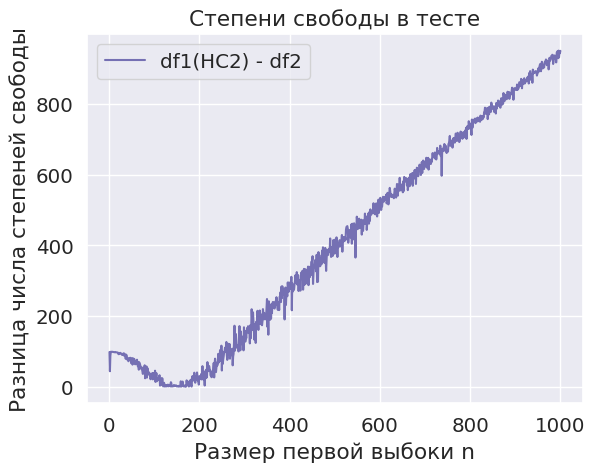

In [217]:
plt.plot(n_grid, df1 - df2, label='df1(HC2) - df2')
plt.xlabel('Размер первой выбоки n')
plt.ylabel('Разница числа степеней свободы')
plt.title('Степени свободы в тесте')
plt.legend()
plt.show()

In [218]:
n_grid = np.arange(1, 1001)
m = 200
df1 = n_grid + m - 2
df2 = np.zeros(len(n_grid))
for i, n in tqdm(enumerate(n_grid)):
    y1 = sps.norm(loc=a, scale=sigma1).rvs(n)
    y2 = sps.norm(loc=b, scale=sigma2).rvs(m)
    df2[i] = sps.ttest_ind(y1, y2, equal_var=False).df

0it [00:00, ?it/s]

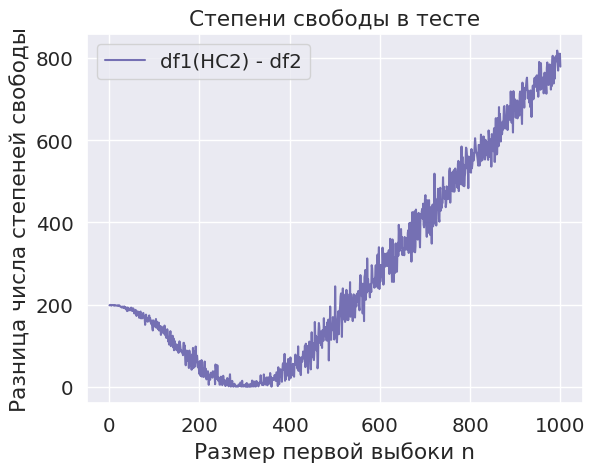

In [219]:
plt.plot(n_grid, df1 - df2, label='df1(HC2) - df2')
plt.xlabel('Размер первой выбоки n')
plt.ylabel('Разница числа степеней свободы')
plt.title('Степени свободы в тесте')
plt.legend()
plt.show()

In [222]:
n_grid = np.arange(1, 10001)
df1 = n_grid + n_grid - 2
df2 = np.zeros(len(n_grid))
for i, n in tqdm(enumerate(n_grid)):
    y1 = sps.norm(loc=a, scale=sigma1).rvs(n)
    y2 = sps.norm(loc=b, scale=sigma2).rvs(n)
    df2[i] = sps.ttest_ind(y1, y2, equal_var=False).df

0it [00:00, ?it/s]

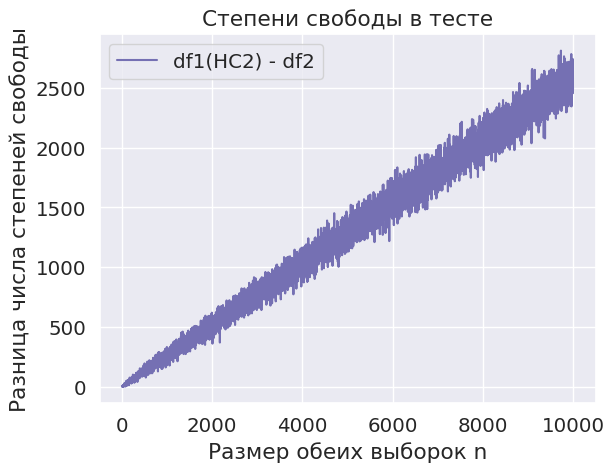

In [223]:
plt.plot(n_grid, df1 - df2, label='df1(HC2) - df2')
plt.xlabel('Размер обеих выборок n')
plt.ylabel('Разница числа степеней свободы')
plt.title('Степени свободы в тесте')
plt.legend()
plt.show()

При увеличении разницы размера выборок разницы значений степеней свободы, вычисленных по формуле Уэлча и по оценке HC2, увеличиваются. То есть поправка HC2 всегда ближе к нормальному распрделению, значит его хвосты тяжелее, а значит по формуле Уэлча значение более консервативно. При малых размерах она тоже сильно выше, примерно на разницу в размерах. При примерно равных размерах они одинаковые

При равномерном увеличении обеих выборок разница тоже растёт равномерно, то есть Уэлч становится всё более консервативен в сравнении

In [224]:
sigma1 = 1
sigma_grid = np.logspace(-2, 3, 10000)
n = 200
m = 100
df1 = n + m - 2
df2 = np.zeros(len(sigma_grid))
for i, sigma in tqdm(enumerate(sigma_grid)):
    y1 = sps.norm(loc=a, scale=sigma1).rvs(n)
    y2 = sps.norm(loc=b, scale=sigma).rvs(m)
    df2[i] = sps.ttest_ind(y1, y2, equal_var=False).df

0it [00:00, ?it/s]

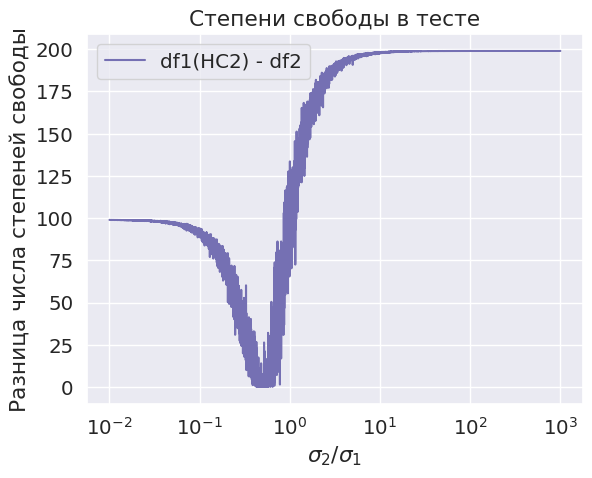

In [225]:
plt.plot(sigma_grid, df1 - df2, label='df1(HC2) - df2')
plt.xlabel(r'$\sigma_2/\sigma_1$')
plt.xscale('log')
plt.ylabel('Разница числа степеней свободы')
plt.title('Степени свободы в тесте')
plt.legend()
plt.show()

Здесь зависимость немонотонная, но тем не менее функция всегда положительная, что свидетельствует так же о выводе, аналогичном предыдущему. Интересно, что с ростом отношения разница выходит снова на константу

In [188]:
sigma1 = 1
theta_grid = np.logspace(-2, 3, 10000)
n = 200
m = 100
df1 = n + m - 2
df2 = np.zeros(len(sigma_grid))
for i, theta in tqdm(enumerate(theta_grid)):
    y1 = sps.norm(loc=a, scale=sigma1).rvs(n)
    y2 = sps.expon(theta).rvs(m)
    df2[i] = sps.ttest_ind(y1, y2, equal_var=False).df

0it [00:00, ?it/s]

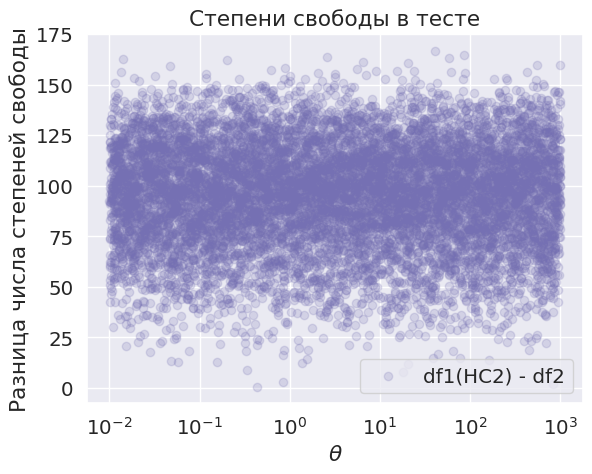

In [193]:
plt.scatter(sigma_grid, df1 - df2, label='df1(HC2) - df2', alpha=0.2)
plt.xlabel(r'$\theta$')
plt.xscale('log')
plt.ylabel('Разница числа степеней свободы')
plt.title('Степени свободы в тесте')
plt.legend()
plt.show()

Тут разница всегда порядка разницы в размерах, Уэлч более консервативен

**2.** Реализуйте функцию построения критериев и доверительных интервалов из задачи SB.9.2. Обратите внимание на следующие особенности функции.
* Аргумент `cov_type` определяет тип поправки на гетероскедастичность. Реализуйте функцию с поправками так, чтобы никакой код не дублировался для разных поправок. Может помочь аргумент `ddof` функции `np.var`.
* Аргумент `axis` определяет ось выборок, по которой будет производиться вычисление статистики. Например, если исходные выборки имели размерности $(n, u, v)$ и $(m, u, v)$, то при значении по умочанию `axis=0` результаты будут иметь размерность $(u, v)$. Функция `scipy.stats.ttest_ind` также имеет аргумент `axis=0`, используйте его для векторизации вычислений в задаче.


In [320]:
def ttest_regression(
    sample_a: np.ndarray,
    sample_b: np.ndarray,
    axis: int = 0,
    cov_type: Literal["HC0", "HC1", "HC2", "HC3"] = "HC3",
    alpha: float = 0.05
) -> Tuple[Union[float, np.ndarray], Union[float, np.ndarray], Union[float, np.ndarray]]:
    """Выполняет t-тест для двух независимых выборок с поправкой на гетероскедастичность.

    Args:
        sample_a, sample_b: Сравниваемые выборки данных.
        axis: Ось, по которой вычисляется статистика.
        cov_type: Тип поправки на гетероскедастичность.
        alpha: Уровень значимости для критерия и доверительного интервала.

    Returns:
        Кортеж (p-value, левая граница д.и., правая граница д.и.) для разности средних.
    """

    n = sample_a.shape[axis]
    m = sample_b.shape[axis]

    mean_a_k = np.mean(sample_a, axis=axis, keepdims=True)
    mean_b_k = np.mean(sample_b, axis=axis, keepdims=True)
    mean_a = np.squeeze(mean_a_k, axis=axis)
    mean_b = np.squeeze(mean_b_k, axis=axis)
    diff = mean_b - mean_a 

    ra = sample_a - mean_a_k
    rb = sample_b - mean_b_k

    S_a_raw = np.sum(ra**2, axis=axis)  
    S_b_raw = np.sum(rb**2, axis=axis)

    if cov_type == "HC0":
        v_a = S_a_raw / (n**2)
        v_b = S_b_raw / (m**2)

    elif cov_type == "HC1":
        v_a = S_a_raw * (n + m) / (n + m - 2) / n**2
        v_b = S_b_raw * (n + m) / (n + m - 2) / m**2

    elif cov_type == "HC2":
        S_a = S_a_raw / (1 - 1 / n)
        S_b = S_b_raw / (1 - 1 / m)
        v_a = S_a / (n**2)
        v_b = S_b / (m**2)

    elif cov_type == "HC3":
        S_a = S_a_raw / (1 - 1 / n) ** 2
        S_b = S_b_raw / (1 - 1 / m) ** 2
        v_a = S_a / (n**2)
        v_b = S_b / (m**2)

    se = np.sqrt(v_a + v_b)
    T = diff / se

    pvalue = 2.0 * sps.t(n + m - 2).sf(np.abs(T))
    tcrit = sps.t(n + m - 2).ppf(1 - alpha / 2)
    left = diff - tcrit * se
    right = diff + tcrit * se

    return pvalue, left, right

Исследуйте зависимость вероятности ошибки первого рода от размера выборки для всех критериев (HC0-HC3 и критерий Уэлша). Рассмотрите различные соотношения дисперсий выборок и типы распределений.

Для оценки вероятности ошибки проведите большое количество семплирований (не менее $10^5$) и используйте векторизацию функций вычисления критериев.

In [321]:
k = 100_000
n = 200
m = 100

sigma1 = 1
sigma2_grid = np.logspace(-1, 3, 10)


hc0 = np.zeros(len(sigma2_grid))
hc1 = np.zeros(len(sigma2_grid))
hc2 = np.zeros(len(sigma2_grid))
hc3 = np.zeros(len(sigma2_grid))
wel = np.zeros(len(sigma2_grid))

for i, sigma2 in enumerate(tqdm(sigma2_grid)):
    y1 = sps.norm(loc=5, scale=sigma1).rvs(size=(k, n))
    y2 = sps.norm(loc=5, scale=sigma2).rvs(size=(k, m))
    
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC0')
    hc0[i] = (pvalue < 0.05).sum() / k
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC1')
    hc1[i] = (pvalue < 0.05).sum() / k
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC2')
    hc2[i] = (pvalue < 0.05).sum() / k
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC3')
    hc3[i] = (pvalue < 0.05).sum() / k
    pvalue = sps.ttest_ind(y1, y2, axis=1, equal_var=False)[1]
    wel[i] = (pvalue < 0.05).sum() / k

100%|███████████████████████████████████████████| 10/10 [01:22<00:00,  8.21s/it]


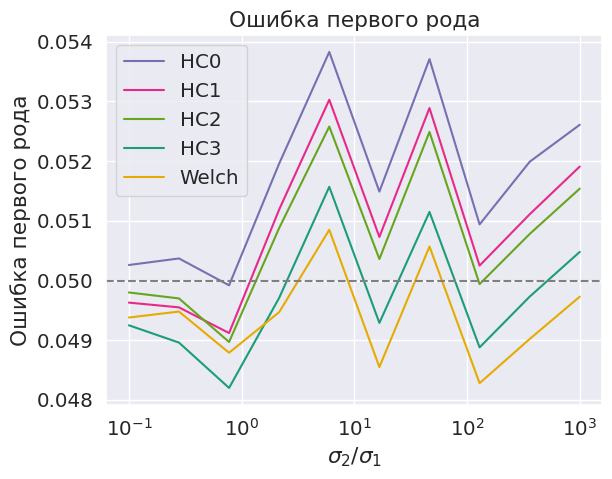

In [322]:
plt.plot(sigma2_grid, hc0, label='HC0')
plt.plot(sigma2_grid, hc1, label='HC1')
plt.plot(sigma2_grid, hc2, label='HC2')
plt.plot(sigma2_grid, hc3, label='HC3')
plt.plot(sigma2_grid, wel, label='Welch')
plt.axhline(0.05, c='gray', linestyle='--')
plt.xlabel(r'$\sigma_2/\sigma_1$')
plt.xscale('log')
plt.ylabel('Ошибка первого рода')
plt.title('Ошибка первого рода')
plt.legend()
plt.show()

In [323]:
k = 100_000
n_grid = np.arange(50, 1050, 50)
m = 100

sigma1 = 1
sigma2 = 2


hc0 = np.zeros(len(n_grid))
hc1 = np.zeros(len(n_grid))
hc2 = np.zeros(len(n_grid))
hc3 = np.zeros(len(n_grid))
wel = np.zeros(len(n_grid))

for i, n in enumerate(tqdm(n_grid)):
    y1 = sps.norm(loc=5, scale=sigma1).rvs(size=(k, n))
    y2 = sps.norm(loc=5, scale=sigma2).rvs(size=(k, m))
    
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC0')
    hc0[i] = (pvalue < 0.05).sum() / k
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC1')
    hc1[i] = (pvalue < 0.05).sum() / k
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC2')
    hc2[i] = (pvalue < 0.05).sum() / k
    pvalue, left, right = ttest_regression(y1, y2, axis=1, cov_type='HC3')
    hc3[i] = (pvalue < 0.05).sum() / k
    pvalue = sps.ttest_ind(y1, y2, axis=1, equal_var=False)[1]
    wel[i] = (pvalue < 0.05).sum() / k

100%|███████████████████████████████████████████| 20/20 [05:11<00:00, 15.57s/it]


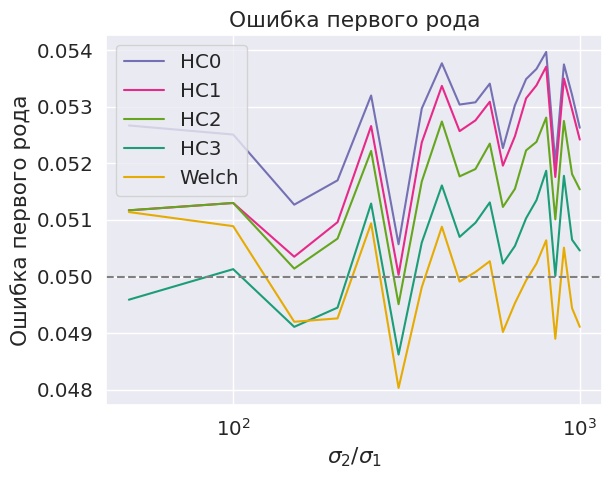

In [324]:
plt.plot(n_grid, hc0, label='HC0')
plt.plot(n_grid, hc1, label='HC1')
plt.plot(n_grid, hc2, label='HC2')
plt.plot(n_grid, hc3, label='HC3')
plt.plot(n_grid, wel, label='Welch')
plt.axhline(0.05, c='gray', linestyle='--')
plt.xlabel(r'$\sigma_2/\sigma_1$')
plt.xscale('log')
plt.ylabel('Ошибка первого рода')
plt.title('Ошибка первого рода')
plt.legend()
plt.show()

**Выводы:** Получается, что Уэлч наиболее консервативен, как и должно быть из исселодваний количества степенй свободы, а далее консервативность идёт в порядке нумерации HC, наиболее консервативна HC3, поэтому её и Уэлча и используют на практике

---
### Задача 2.

Вспомним задачу 2 из практического задания SM.9 🤩

Загрузите данные и разделите на две части.

In [234]:
from typing import Union
Coordinate = Union[float, np.ndarray, pd.Series]

def haversine(lat1: Coordinate, lon1: Coordinate, lat2: Coordinate, lon2: Coordinate) -> np.ndarray:
    """
    Вычисляет расстояние между двумя точками на Земле по формуле гаверсина.

    Параметры
    ----------
    lat1: Широта первой точки в градусах.
    lon1: Долгота первой точки в градусах.
    lat2: Широта второй точки в градусах.
    lon2: Долгота второй точки в градусах.

    Возвращает
    -------
    np.ndarray
        Расстояние между точками в километрах.
    """
    R = 6371.0  # Средний радиус Земли в километрах

    # Преобразование градусов в радианы для вычислений
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    # Основная формула Гаверсина
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    # Использование arctan2 для большей точности
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [235]:
df = pd.read_csv("train.csv", parse_dates=["pickup_datetime", "dropoff_datetime"])
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [236]:
df["trip_duration_min"] = df["trip_duration"] / 60.0
df["distance_km"] = haversine(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"],
)
df["speed"] = df["distance_km"] / (df["trip_duration_min"] / 60)
# День недели (0 = понедельник)
df["weekday"] = df["pickup_datetime"].dt.weekday
# Выходные
df["is_weekend"] = (df["weekday"] >= 5).astype(int)
# Часы
df["hour"] = df["pickup_datetime"].dt.hour
# Утренний час-пик
df["is_peak_morning"] = df["hour"].between(7, 10).astype(bool)
# Вечерний час-пик
df["is_peak_evening"] = df["hour"].between(16, 20).astype(bool)
df['is_peak'] = (df["is_peak_morning"] + df["is_peak_evening"]).astype(int)
# некоторые признаки можно убрать
df["dist_peak"] = df["distance_km"] * df["is_peak"]
df["dist_weekend"] = df["distance_km"] * df["is_weekend"]
df["dist2"] = df["distance_km"] ** 2
df["log_dist"] = np.log1p(df["distance_km"])

# придумайте свои признаки исходя из постановки задачи
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
X = df.drop(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 
             'store_and_fwd_flag', 'trip_duration', 'trip_duration_min', 
             'speed', 'is_peak_morning', 'is_peak_evening'], axis=1)
y = df['trip_duration_min']

In [237]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

column = 'distance_km'
data = X_train[column]
q1 = np.quantile(data, 0.25)
q3 = np.quantile(data, 0.75)
iqr = q3 - q1
mask = (data >= q1 - 1.5 * iqr) & (data <= 20)

print(f"Из столбца '{column}' удалено {100 - mask.sum() / len(data) * 100:.2f}% данных")
X_train_out = X_train[mask]
y_train_out = y_train[mask]

data = y_train_out
q1 = np.quantile(data, 0.25)
q3 = np.quantile(data, 0.75)
iqr = q3 - q1
mask = (data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)

print(f"Из столбца '{y.name}' удалено {100 - mask.sum() / len(data) * 100:.2f}% данных")
X_train_out = X_train_out[mask]
y_train_out = y_train_out[mask]

mask = X_train_out['distance_km'] > 0
X_train_out = X_train_out.loc[mask, :]
y_train_out = y_train_out[mask]

speed = X_train_out['distance_km'] / (y_train_out / 60)
mask = (speed <= 90)
X_train = X_train_out[mask]
y_train = y_train_out[mask]

X_train = X_train.drop(['month', 'day', 'dist2', 'weekday', 'dist_weekend', 'dist_peak'], axis=1)
X_test = X_test.drop(['month', 'day', 'dist2', 'weekday', 'dist_weekend', 'dist_peak'], axis=1)

Из столбца 'distance_km' удалено 1.63% данных
Из столбца 'trip_duration_min' удалено 4.31% данных


In [238]:
y_train = np.log1p(y_train)

In [239]:
cat_cols = ['passenger_count', 'is_weekend', 'is_peak', 'hour']
X_train.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,is_weekend,hour,is_peak,log_dist
1053743,1,-73.862762,40.768822,-73.891701,40.746689,3.463778,0,18,1,1.495996
273748,1,-73.958038,40.783237,-73.975510,40.760853,2.891365,0,13,0,1.358760
433988,1,-73.969460,40.785519,-73.989243,40.771748,2.262636,1,12,0,1.182536
1442481,1,-73.981743,40.736549,-73.998352,40.726440,1.795030,1,18,1,1.027843
1025834,1,-73.977913,40.752609,-73.975647,40.733139,2.173389,1,22,0,1.154800


Постройте предсказание длительности поездки с помощью CatBoost. Не забудьте, что CatBoost умеет эффективно работать с категориальными признаками. Предсказание должно быть монотонным по длине поездки. Иначе говоря, при увеличении расстояния поездки и *фиксированных* остальных признаках *среднее* время поездки не может уменьшаться.

Оцените качество полученного предсказания по MAPE на тестовой выборке и сравните с полученным значением из SM.9.

In [220]:
%%time

param_distributions = {
    'n_estimators': np.arange(50, 300),
    'max_depth': np.arange(3, 8),
    'learning_rate': np.linspace(0.01, 0.3, 50),
    'min_data_in_leaf': np.arange(1, 7),
    'l2_leaf_reg': np.linspace(0, 10, 20),
    'rsm': np.linspace(0.5, 1, 10).astype(float)
}

base_model = CatBoostRegressor(
    cat_features=cat_cols,
    random_state=RANDOM_STATE,
    verbose=False,
    monotone_constraints=[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    loss_function='MAPE'
)

CatBoost_CV = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    scoring='neg_mean_absolute_error',
    n_iter=30,
    n_jobs=-1,
    cv=5,
    random_state=RANDOM_STATE,
    verbose=1
)

CatBoost_CV.fit(X_train, y_train)    
#Учил в коллабе
CatBoost_CV.best_estimator_.save_model("catboost_best.cbm")
files.download("catboost_best.cbm")                 

In [240]:
model = CatBoostRegressor()
model.load_model("catboost_best.cbm")
score = model.best_score_['learn']['MAPE']
print(f'Лучшая метрика: {score:.2f}')

Лучшая метрика: 0.10


In [246]:
print(f'MAPE: {mean_absolute_percentage_error(y_test, np.expm1(model.predict(X_test))):.2f}')

MAPE: 0.27


Обучите еще две модели CatBoost для построения предсказательного интервала для фактического времени поездки. Постройте интервал по сетке значений расстояния аналогично SM.9.

In [73]:
%%time

alpha = 0.05
iterations = 500
lower = CatBoostRegressor(
        loss_function=f"Quantile:alpha={alpha/2}", iterations=iterations, verbose=0, cat_features=cat_cols, 
    ).fit(X_train, y_train)
upper = CatBoostRegressor(
        loss_function=f"Quantile:alpha={1-alpha/2}", iterations=iterations, verbose=0, cat_features=cat_cols,
    ).fit(X_train, y_train)

CPU times: user 23min 13s, sys: 2min 16s, total: 25min 29s
Wall time: 4min 26s


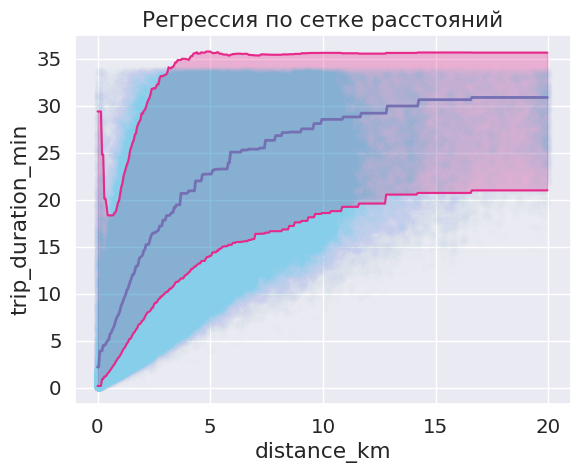

In [247]:
train = pd.concat([X_train, y_train], axis=1)
grid = np.arange(0, 20, 0.05)
n = len(grid)
train_grid = pd.DataFrame(train[:n])
for column in X_test.columns:
    train_grid.loc[:, column] = np.median(train[column], axis=0)
train_grid['distance_km'] = grid
train_grid['log_dist'] = np.log1p(grid)
lower_pred = np.expm1(lower.predict(train_grid))
pred = np.expm1(CatBoost_CV.predict(train_grid))
upper_pred = np.expm1(upper.predict(train_grid))
plt.plot(grid, lower_pred, c='C1')
plt.plot(grid, pred, c='C0', lw=2)
plt.plot(grid, upper_pred, c='C1')
plt.fill_between(grid, lower_pred, upper_pred, alpha=0.3, color='C1')
sns.scatterplot(x=train['distance_km'], y=np.expm1(y_train), alpha=0.01, color='skyblue')
plt.title('Регрессия по сетке расстояний')
plt.xlabel('distance_km')
plt.ylabel('trip_duration_min')
plt.show()

Оцените долю покрытия предсказательным интервалом *фактического* времени поездки по *всем* точкам тестовой выборки.

In [51]:
def estimate_coverage(y_test: Union[pd.Series, np.ndarray], y_preds: pd.DataFrame) -> float:
    """Оценивает покрытие предсказательного интервала.

    Args:
        y_test (Union[pd.Series, np.ndarray]): Истинные значения целевой переменной.
        y_preds (pd.DataFrame): DataFrame с предсказанными границами интервала ('lower', 'upper').

    Returns:
        float: Значение покрытия (доля истинных значений, попавших в интервал).
    """
    y_test = np.array(y_test)
    y_lower = np.array(y_preds["lower"])
    y_upper = np.array(y_preds["upper"])

    coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
    return float(coverage)

In [75]:
a = estimate_coverage(y_test, pd.DataFrame({'lower': np.expm1(lower.predict(X_test)), 'upper': np.expm1(upper.predict(X_test))}))
print(f'Доля покрытия предсказательным интервалом фактического времени поездки по всем точкам тестовой выборки: {a:.2f}')

Доля покрытия предсказательным интервалом фактического времени поездки по всем точкам тестовой выборки: 0.90


**Выводы:**

Таким образом, используя квантильную лосс функцию, можно строить предсказательные интервалы для моделеё произвольной сложности. Доля покрытия недооценена, но тем не менее достаточно высокая: 0.9. Получилось построить лучшую модель и предскзаательный интервал для ней. Реальный уровень доверия также получился выше, чем для линейной регрессии

---
### Задача 3.

Кардиотокография (КТГ) — непрерывная одновременная регистрация частоты сердечных сокращений плода и
тонуса матки с графическим изображением физиологических сигналов на калибровочной ленте. В настоящее
время КТГ является ведущим методом наблюдения за характером сердечной деятельности, который из-за
своей простоты в проведении, информативности и стабильности получаемой информации практически
полностью вытеснил из клинической практики фоно- и электрокардиографию плода.

Для облегчения задачи диагностики, результаты кардиотокографии некоторых эмбрионов были
классифицированы специалистами на нормальные и патологические. По показаниям приборов было
сгенерировано некоторое количество признаков.

**1.** Скачайте данные по ссылке: https://archive.ics.uci.edu/ml/datasets/cardiotocography.
Данные расположены в листе `Data`. Рассматриваемые нами признаки указаны в листе Description в колонке Features. Целевой меткой является столбец `NSP`. Для анализа мы не будем рассматривать данные, целевой меткой которой является `Suspect`.

In [6]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cardiotocography = fetch_ucirepo(id=193) 
  
# data (as pandas dataframes) 
X = cardiotocography.data.features 
y = cardiotocography.data.targets 
  
# metadata 
print(cardiotocography.metadata) 
  
# variable information 
print(cardiotocography.variables) 

{'uci_id': 193, 'name': 'Cardiotocography', 'repository_url': 'https://archive.ics.uci.edu/dataset/193/cardiotocography', 'data_url': 'https://archive.ics.uci.edu/static/public/193/data.csv', 'abstract': 'The dataset consists of measurements of fetal heart rate (FHR) and uterine contraction (UC) features on cardiotocograms classified by expert obstetricians.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 2126, 'num_features': 21, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['CLASS', 'NSP'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C51S4N', 'creators': ['D. Campos', 'J. Bernardes'], 'intro_paper': None, 'additional_info': {'summary': '2126 fetal cardiotocograms (CTGs) were automatically processed and the respective diagnostic features measured. The CTGs were also classified

In [7]:
y.head()

,CLASS,NSP
0,9,2
1,6,1
2,6,1
3,6,1
4,2,1


In [8]:
y = y.drop(['CLASS'], axis=1)
mask1 = (y == 1).values.reshape(-1)
mask2 = (y != 2).values.reshape(-1)
mask3 = (y == 3).values.reshape(-1)
y[mask1] = y[mask1] - 1
y[mask3] = y[mask3] - 2
y = y[mask2]
X = X.loc[mask2, :]
X.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
1,132,0.006,0.0,0.006,0.003,0.0,0.000,17,2.1,0,...,130,68,198,6,1,141,136,140,12,0
2,133,0.003,0.0,0.008,0.003,0.0,0.000,16,2.1,0,...,130,68,198,5,1,141,135,138,13,0
3,134,0.003,0.0,0.008,0.003,0.0,0.000,16,2.4,0,...,117,53,170,11,0,137,134,137,13,1
4,132,0.007,0.0,0.008,0.000,0.0,0.000,16,2.4,0,...,117,53,170,9,0,137,136,138,11,1
5,134,0.001,0.0,0.010,0.009,0.0,0.002,26,5.9,0,...,150,50,200,5,3,76,107,107,170,0


In [9]:
print(X.shape)
X.isna().sum().any()

(1831, 21)


np.False_

**2.** Проведите визуальный анализ данных. Какие признаки лучше всего разделяют классы?

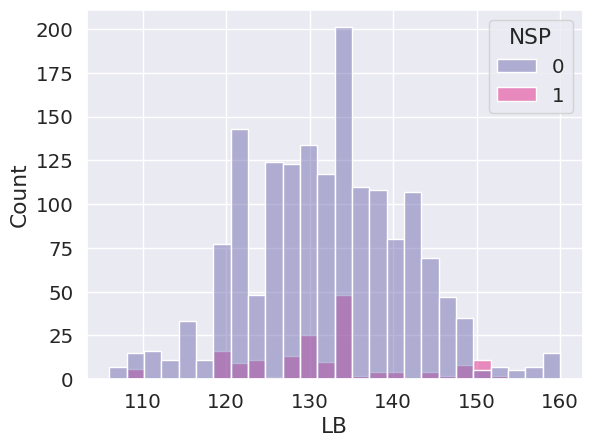

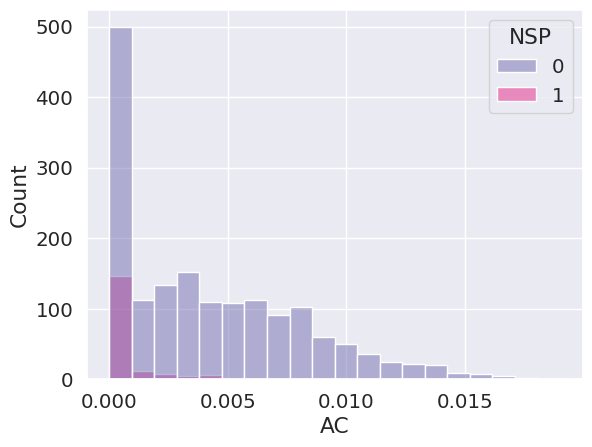

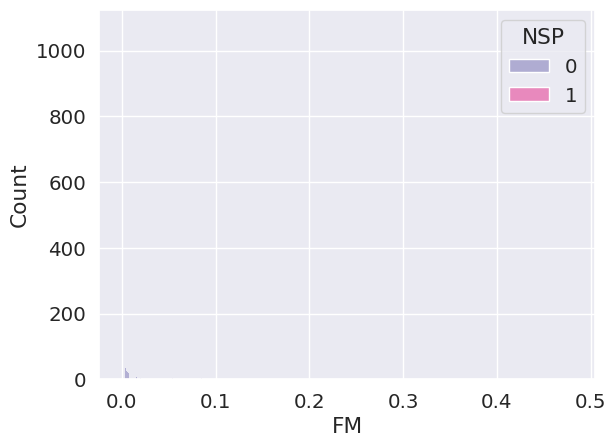

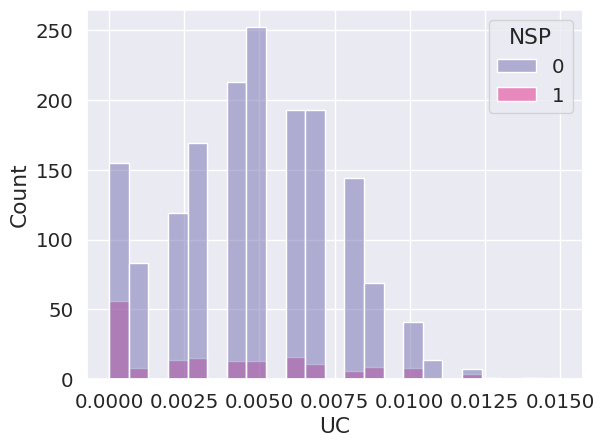

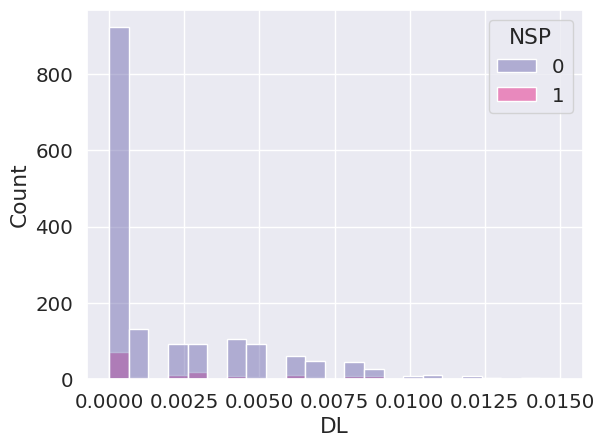

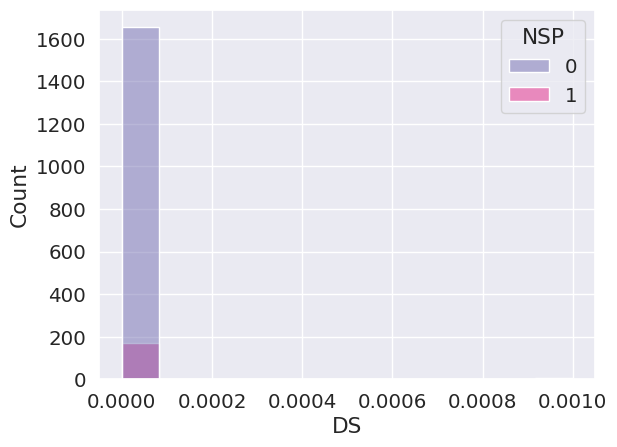

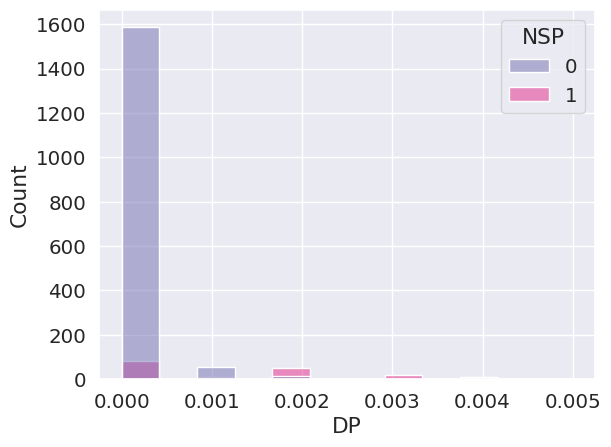

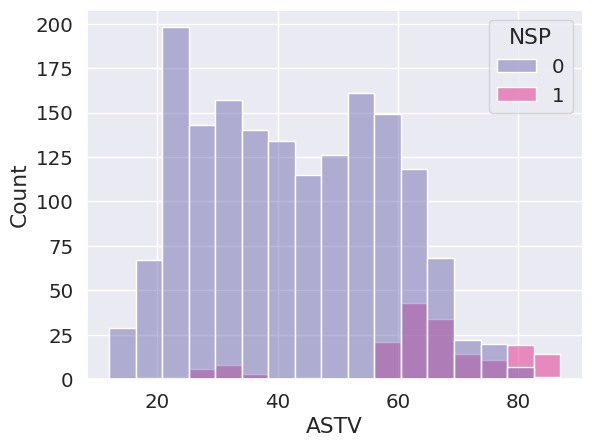

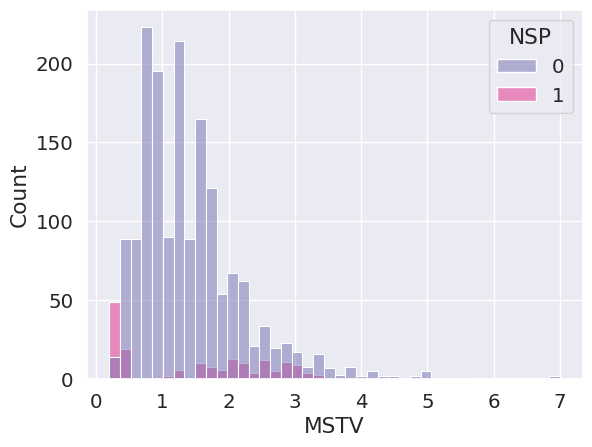

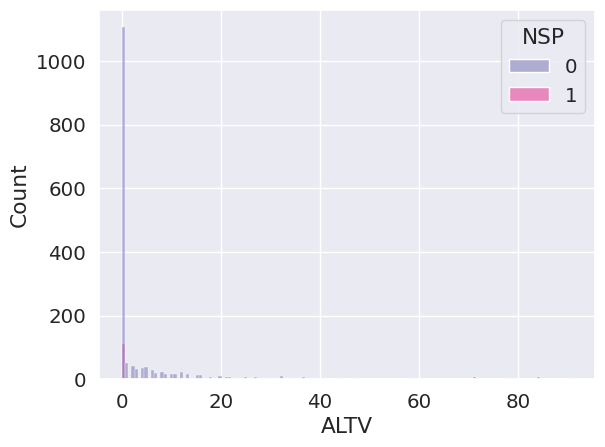

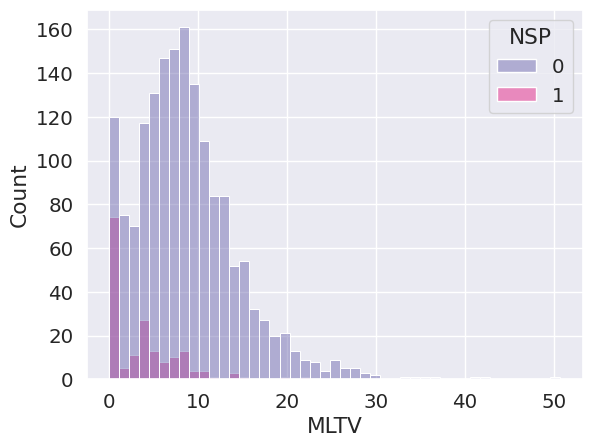

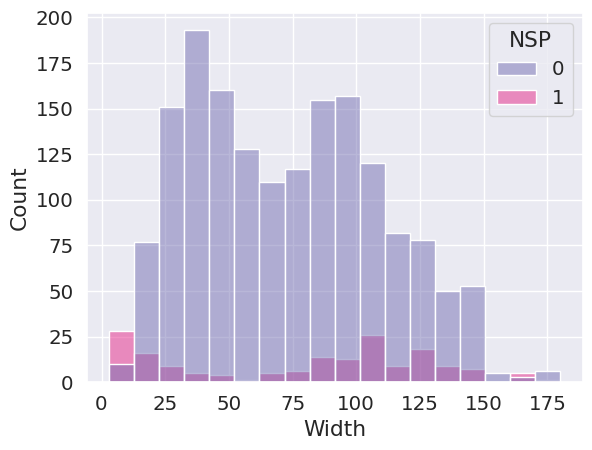

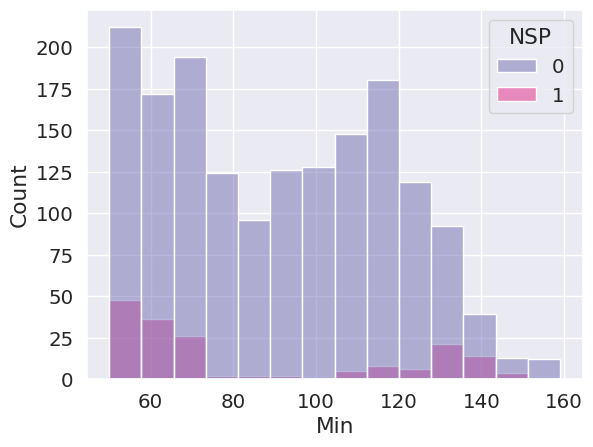

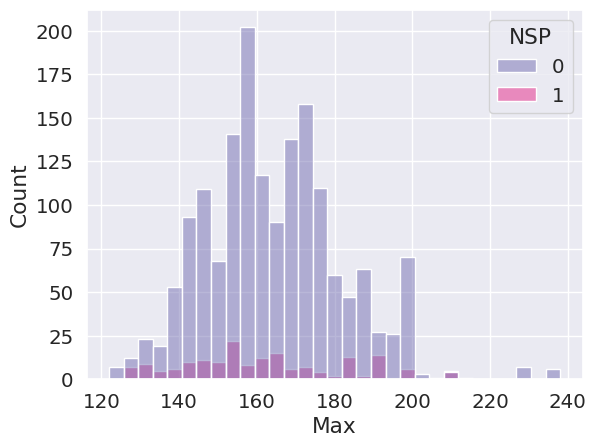

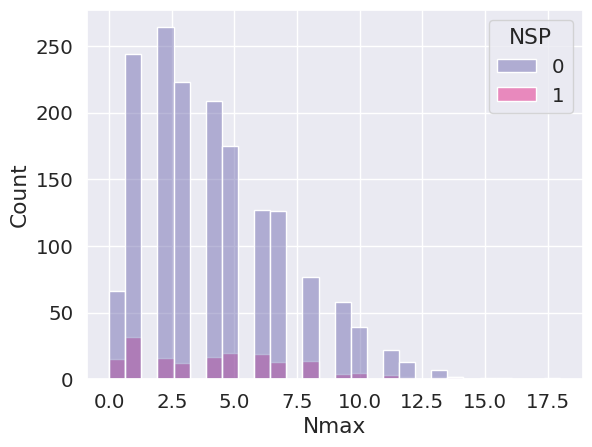

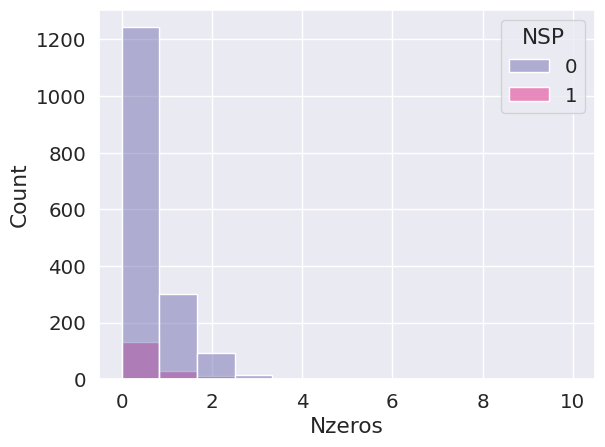

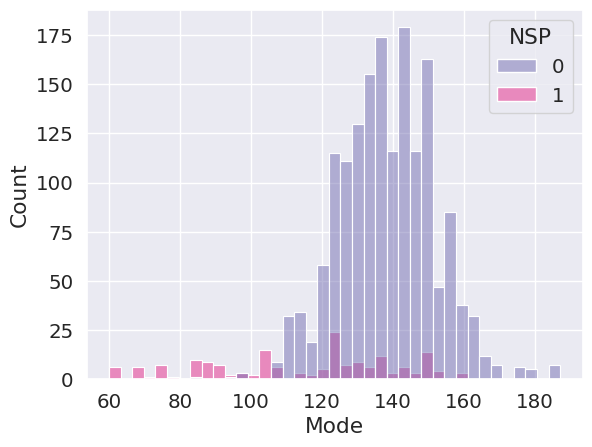

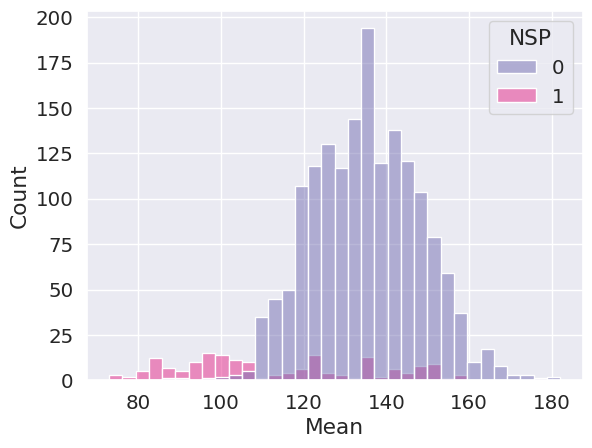

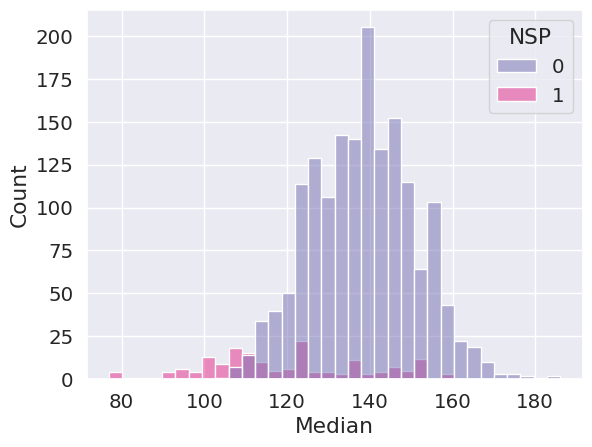

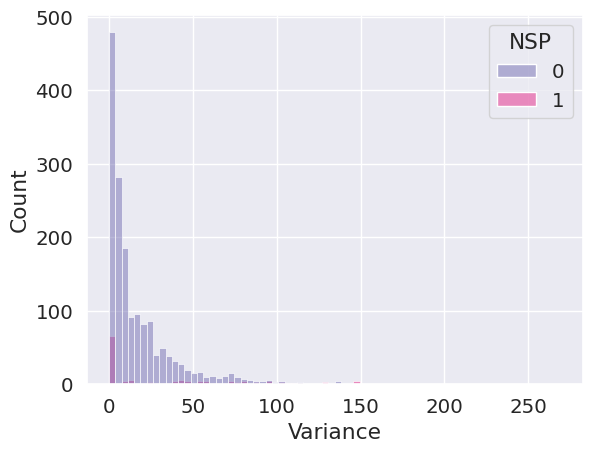

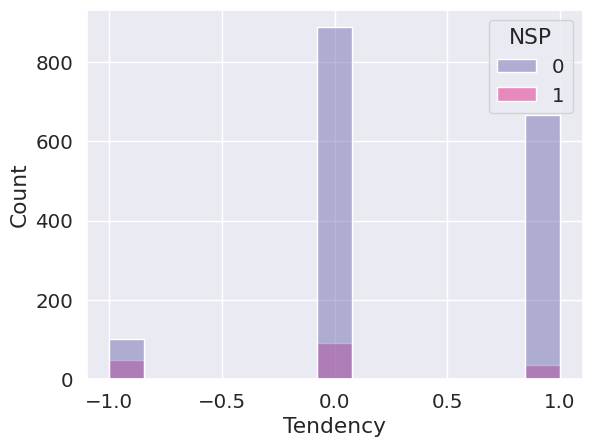

In [180]:
data = pd.concat([X, y], axis=1)
for column in X.columns:
    sns.histplot(data, x=column, hue='NSP')
    plt.show()

Лучше всего данные разделяются по ASTV, LB, mean/median/mode(преподолжительно скоррелированы)

In [191]:
data.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
       'Median', 'Variance', 'Tendency', 'NSP'],
      dtype='object')

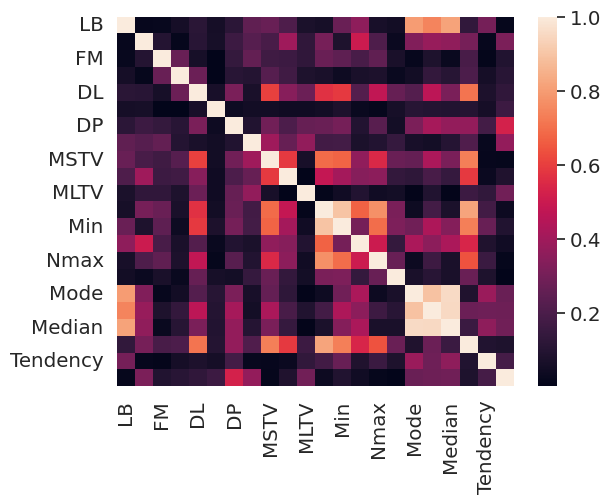

In [181]:
sns.heatmap(np.abs(data.corr('spearman')))
plt.show()

**3.** Разделите выборку на обучающую и тестовую часть случайным образом в соотношении 4:1.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

**4.** Обучите логистическую регрессию по всем признакам. Напечатайте `summary` модели.
В чем причины такого поведения модели? Какие выводы можно сделать? Что нужно сделать, чтобы это исправить?

Без скейлинга

In [11]:
data_train = pd.concat([X_train, y_train], axis=1)
all_params = '+'.join(X_train.columns)
glm_model = smf.glm('NSP' + '~' + all_params, data_train, family=sm.families.Binomial())
glm_results = glm_model.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1373
Model:                            GLM   Df Residuals:                     1352
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39.830
Date:                Sun, 16 Nov 2025   Deviance:                       79.661
Time:                        11:28:57   Pearson chi2:                     172.
No. Iterations:                    12   Pseudo R-squ. (CS):             0.4463
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -28.4924      8.738     -3.261      0.0

Большой std err некоторых коэффициентов, он порядка самих коэффицентов: численная нестабильность

Со скейлингом

In [12]:
cat_cols = ['Tendency']
num_cols = X.columns.difference(cat_cols)

In [13]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
enc = ohe.fit_transform(X_train[cat_cols])
enc = pd.DataFrame(enc, columns=ohe.get_feature_names_out(), index=X_train.index)

In [14]:
scaler = StandardScaler()
sc = scaler.fit_transform(X_train[num_cols])
sc = pd.DataFrame(sc, columns=num_cols, index=X_train.index)

In [15]:
X_train_transformed = pd.concat([enc, sc], axis=1)
data_train_transformed = pd.concat([X_train_transformed, y_train], axis=1)

In [16]:
all_params = '+'.join(X_train_transformed.columns)
glm_model = smf.glm('NSP' + '~' + all_params, data_train_transformed, family=sm.families.Binomial())
glm_results = glm_model.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1373
Model:                            GLM   Df Residuals:                     1351
Model Family:                Binomial   Df Model:                           21
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39.818
Date:                Sun, 16 Nov 2025   Deviance:                       79.636
Time:                        11:29:17   Pearson chi2:                     172.
No. Iterations:                   100   Pseudo R-squ. (CS):             0.4463
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -16.0515      2.796     -5.741      0.0

Коэффиценты улетели в бесконечность

Нужно делать отбор признаков либо пользоваться регуляризацией

In [17]:
print(np.linalg.matrix_rank(X_train))
print(np.linalg.matrix_rank(X_train.drop(['Width'], axis=1)))

20
20


In [18]:
data_train_transformed_dropped = data_train_transformed.drop(['Width'], axis=1)
all_params = '+'.join([col for col in data_train_transformed_dropped.columns if col != 'NSP'])
glm_model = smf.glm('NSP ~ ' + all_params, data_train_transformed_dropped, family=sm.families.Binomial())
glm_results = glm_model.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1373
Model:                            GLM   Df Residuals:                     1351
Model Family:                Binomial   Df Model:                           21
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39.818
Date:                Sun, 16 Nov 2025   Deviance:                       79.636
Time:                        11:29:33   Pearson chi2:                     173.
No. Iterations:                    12   Pseudo R-squ. (CS):             0.4463
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -16.0867      2.861     -5.623      0.0

Так стало лучше, однаков признаки всё ещё сильно скорелированы. Также эта модель работает в предположении моделей: логиты линейны по признакам

**5.** Проверьте модель на линейность по значимым признакам, используя сглаженные диаграммы рассеивания. Для избежания влияния выбросов стройте диаграммы в интервале от 0.05-квантили до 0.95-квантили по значениям каждого признака. В качестве ширины ядра берите треть этого диапазона. Какие выводы можно сделать?

In [19]:
alpha = 0.05
imp = glm_results.pvalues[glm_results.pvalues < alpha]
imp_cols = [col for col in imp.index.values if col != 'Intercept']
imp_cols

['ALTV',
 'ASTV',
 'DP',
 'LB',
 'Max',
 'Median',
 'Nmax',
 'Nzeros',
 'UC',
 'Variance']

Выбранные до этого хорошо разделимые признаки есть среди важных

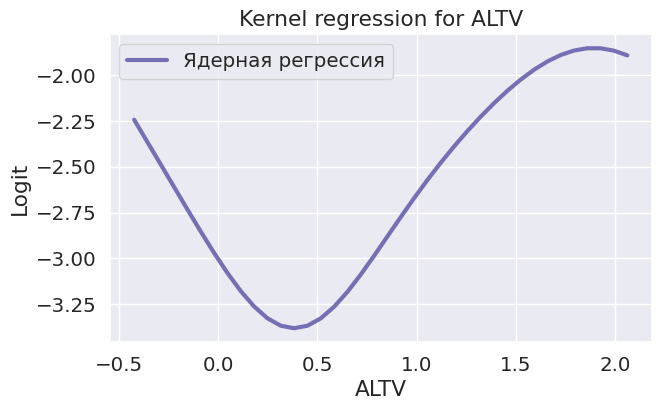

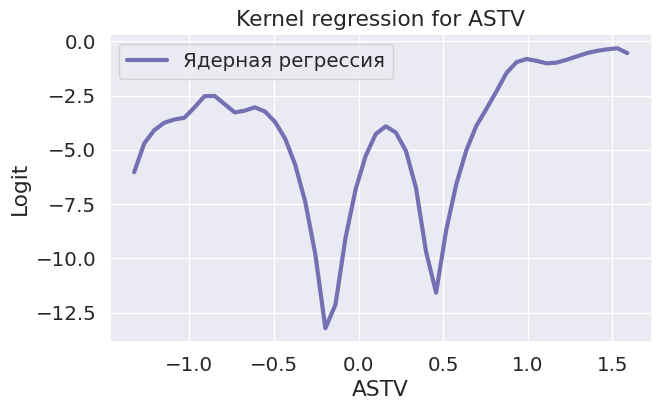

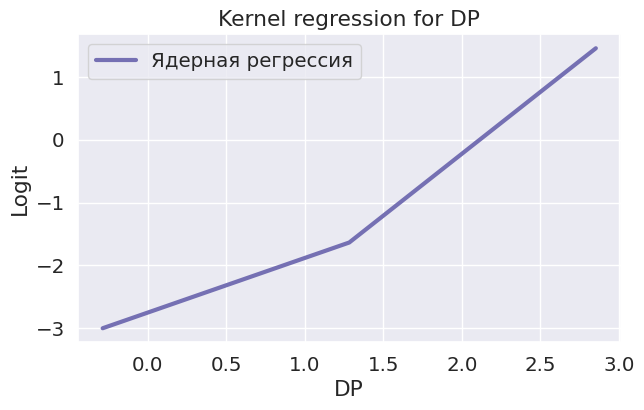

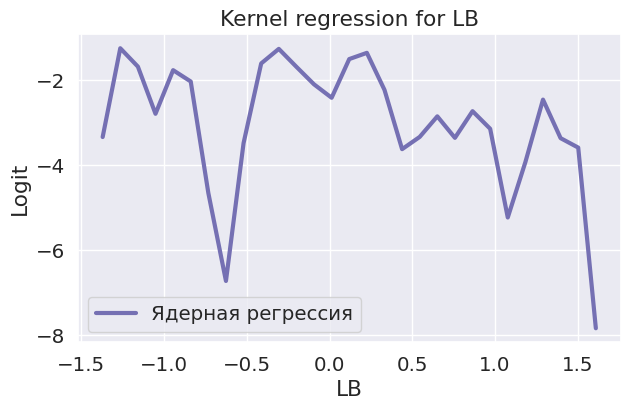

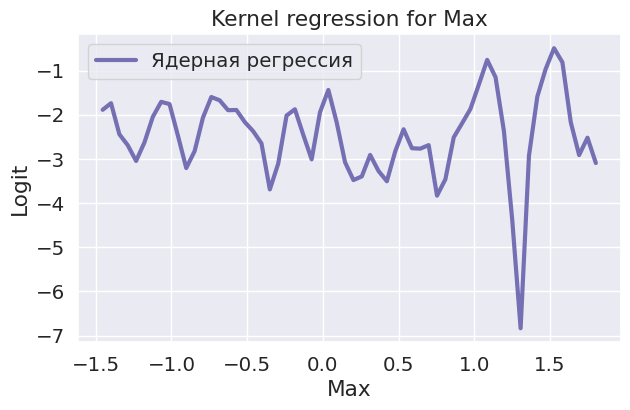

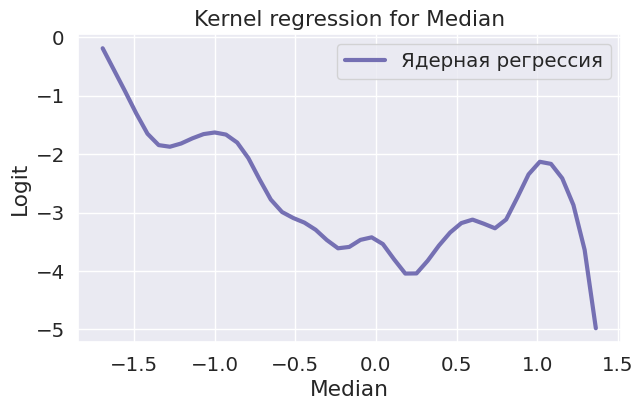

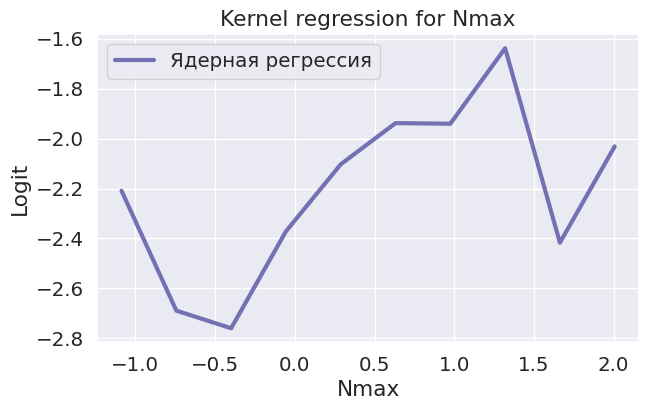

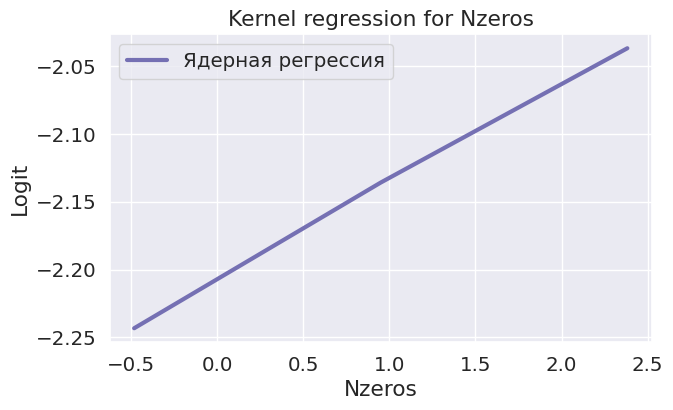

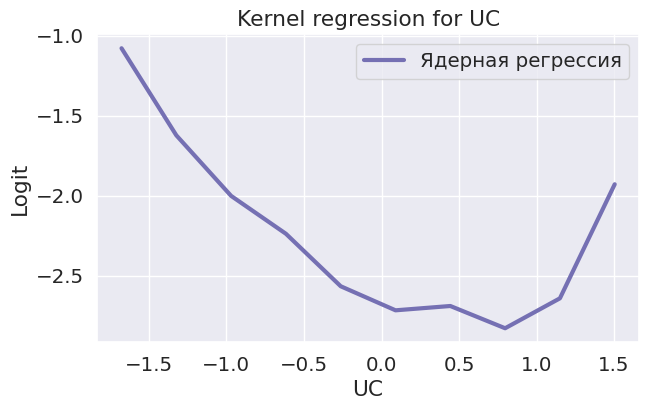

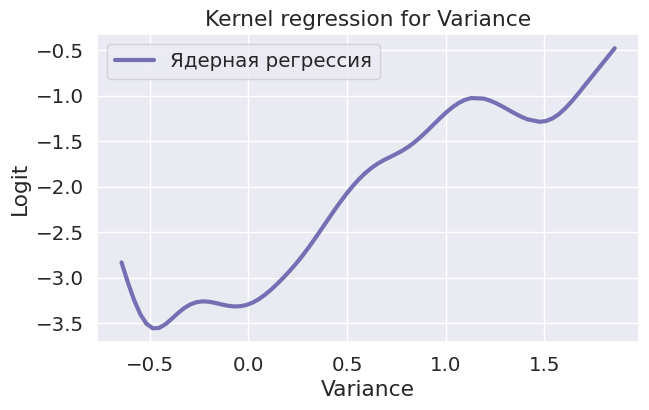

In [240]:
alpha = 0.05

for column in imp_cols:
    x = X_train_transformed[column]
    q1, q2 = np.quantile(x, alpha), np.quantile(x, 1 - alpha)
    mask = (x >= q1) & (x <= q2)
    x_sel = x[mask]
    y_sel = y_train[mask]

    reg = KernelReg(endog=y_sel.values, exog=x_sel.values[:, None], var_type='c')
    y_pred, y_std = reg.fit()
    
    order = np.argsort(x_sel.values)
    xs = x_sel.values[order]
    y_pred = y_pred[order]
    logits = np.log(y_pred / (1 - y_pred))
    
    plt.figure(figsize=(7,4))
    plt.plot(xs, logits, lw=3, label="Ядерная регрессия")
    plt.xlabel(column)
    plt.ylabel("Logit")
    plt.title(f"Kernel regression for {column}")
    plt.legend()
    plt.show()

Видим, что почти линейный признак есть DP и идеально линейный Nzeros. По остальным линейность отсутствует

**6.** Можно ли для каких-то из признаков, по которым не подтвердилась линейность модели, добиться линейности с помощью преобразований? В качестве преобразований можно использовать логарифмирование, возведение в квадрат, взятие модуля, сдвиг, введение нескольких признаков и т.д..

Попрошу гпт нагенерить преобразования

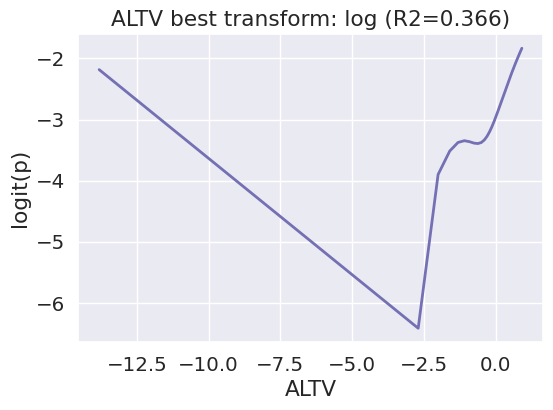

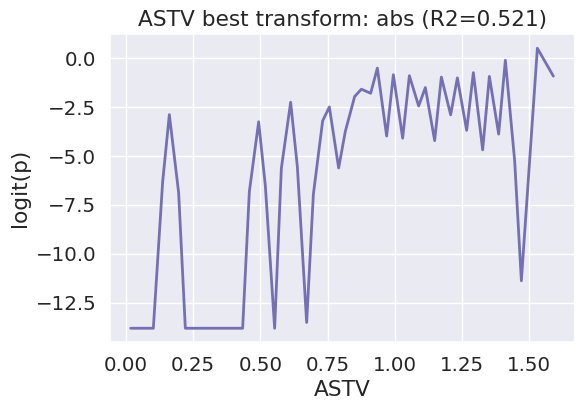

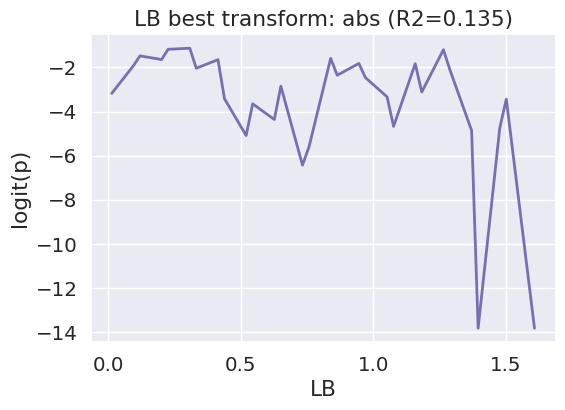

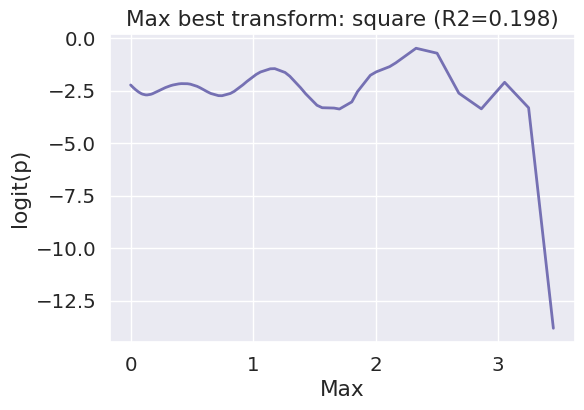

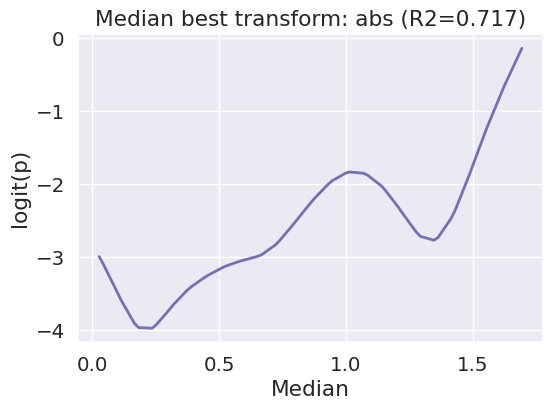

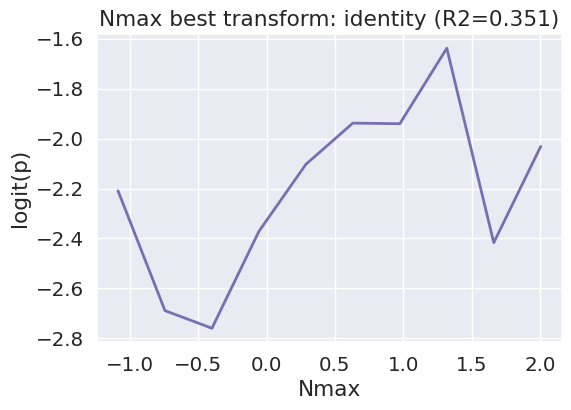

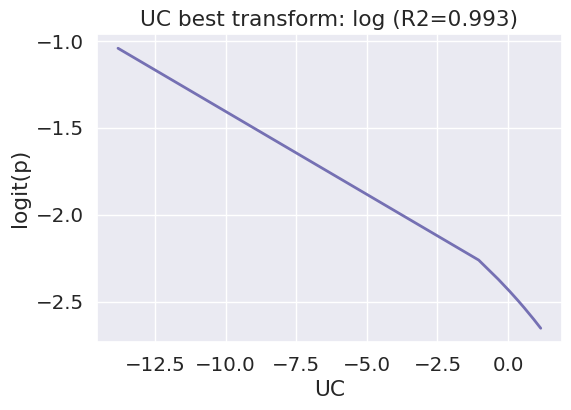

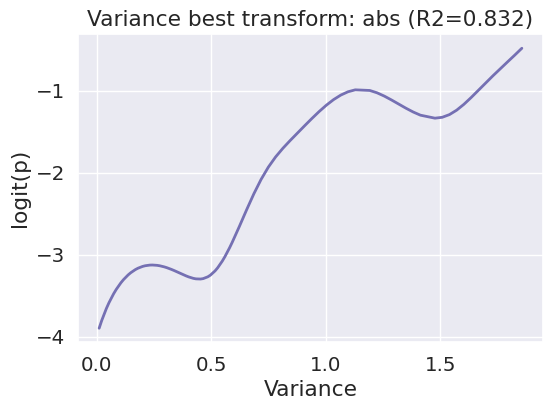

Best transforms: {'ALTV': 'log', 'ASTV': 'abs', 'LB': 'abs', 'Max': 'square', 'Median': 'abs', 'Nmax': 'identity', 'UC': 'log', 'Variance': 'abs'}


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression
from scipy.stats import boxcox

eps = 1e-6

def transformations(x):
    x = np.asarray(x).ravel()
    xm = x.min()
    shifted = x - xm + eps
    out = {
        "identity": x,
        "log": np.log(shifted),
        "sqrt": np.sqrt(shifted),
        "square": x**2,
        "abs": np.abs(x),
        "inv": 1/(x + eps),
    }
    try:
        out["boxcox"], _ = boxcox(shifted)
    except Exception:
        pass
    return out

def safe_enough(xt):
    xt = np.asarray(xt).ravel()
    if len(xt) < 20:
        return False
    if np.isnan(xt).any() or np.isinf(xt).any():
        return False
    if np.unique(xt).size < 8:
        return False
    return True

def smooth_prob(y_sel, xt):
    xt = np.asarray(xt).ravel()
    y_sel = np.asarray(y_sel).ravel()
    order = np.argsort(xt)
    xs = xt[order]
    ys = y_sel[order]
    if not safe_enough(xs):
        low = lowess(ys, xs, frac=0.3)
        return low[:,0], low[:,1], np.zeros_like(low[:,1])
    try:
        kr = KernelReg(endog=ys, exog=xs[:, None], var_type='c')
        yp, ystd = kr.fit()
        order2 = np.argsort(xs)  # already sorted, but be safe
        return xs[order2], yp[order2], ystd[order2].ravel()
    except Exception as e:
        # fallback
        low = lowess(ys, xs, frac=0.3)
        return low[:,0], low[:,1], np.zeros_like(low[:,1])

# Пример использования перебора и выбора лучшего преобразования
best_map = {}
for column in imp_cols:
    x = X_train_transformed[column]
    q1, q2 = np.quantile(x, 0.05), np.quantile(x, 0.95)
    mask = (x >= q1) & (x <= q2)
    x_sel = x[mask]
    y_sel = y_train[mask]

    best_score = -np.inf
    best_res = None

    for name, xt in transformations(x_sel).items():
        xs_smooth, p_smooth, _ = smooth_prob(y_sel, xt)
        p_smooth = np.clip(p_smooth, 1e-6, 1-1e-6)
        logit = np.log(p_smooth / (1 - p_smooth))
        # compute linearity score
        if np.unique(xs_smooth).size < 5:
            score = -np.inf
        else:
            lr = LinearRegression().fit(xs_smooth.reshape(-1,1), logit)
            score = lr.score(xs_smooth.reshape(-1,1), logit)
        if score > best_score:
            best_score = score
            best_res = (name, xs_smooth, logit)

    if best_res is not None:
        name, xs_best, logit_best = best_res
        best_map[column] = name
        plt.figure(figsize=(6,4))
        plt.plot(xs_best, logit_best, lw=2)
        plt.title(f"{column} best transform: {name} (R2={best_score:.3f})")
        plt.xlabel(column)
        plt.ylabel("logit(p)")
        plt.show()

print("Best transforms:", best_map)

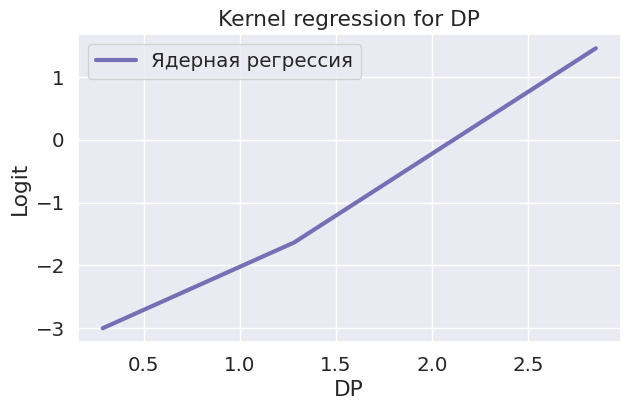

In [37]:
column = 'DP'
x = X_train_transformed[column]
x = np.abs(x)
q1, q2 = np.quantile(x, alpha), np.quantile(x, 1 - alpha)
mask = (x >= q1) & (x <= q2)
x_sel = x[mask]
y_sel = y_train[mask]

reg = KernelReg(endog=y_sel.values, exog=x_sel.values[:, None], var_type='c')
y_pred, y_std = reg.fit()

order = np.argsort(x_sel.values)
xs = x_sel.values[order]
y_pred = y_pred[order]
logits = np.log(y_pred / (1 - y_pred))

plt.figure(figsize=(7,4))
plt.plot(xs, logits, lw=3, label="Ядерная регрессия")
plt.xlabel(column)
plt.ylabel("Logit")
plt.title(f"Kernel regression for {column}")
plt.legend()
plt.show()

**7.** Оставьте только значимые и преобразованные признаки, обучите модель еще раз и проинтерпретируйте полученные результаты. Какой смысл имеют коэффициенты модели?

Оставим DP_abs, Median_abs, UC_log, Varinace_abs. Не забываем, что это отскейленные признаки, к ним затем применили указанные преобразования

In [47]:
eps = 1e-6
new_cols = ['DP_abs', 'Median_abs', 'UC_log', 'Variance_abs']
X_train_scaled_new = {}
X_train_scaled_new['DP_abs'] = np.abs(X_train_transformed['DP'])
X_train_scaled_new['Median_abs'] = np.abs(X_train_transformed['Median'])
X_train_scaled_new['UC_log'] = np.log(X_train_transformed['UC'] - X_train_transformed['UC'].min() + eps)
X_train_scaled_new['Variance_abs'] = np.abs(X_train_transformed['Variance'])
X_train_scaled_new = pd.DataFrame(X_train_scaled_new, columns=new_cols)
data_train_scaled_new = pd.concat([X_train_scaled_new, y_train], axis=1)

In [49]:
all_params = '+'.join(new_cols)
glm_model = smf.glm('NSP' + '~' + all_params, data_train_scaled_new, family=sm.families.Binomial())
glm_results = glm_model.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1373
Model:                            GLM   Df Residuals:                     1368
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -205.23
Date:                Sun, 16 Nov 2025   Deviance:                       410.46
Time:                        12:53:37   Pearson chi2:                 1.18e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2955
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -6.2322      0.385    -16.176   

При изменении какого-либо признака на единицу, логит меняется на значение коэффициента. Значит $e^{\theta_j}$ есть отношение шансов при изменении признака на единицу, то есть то, во сколько увеличивается раз вероятность класса 1 по отношению к вероятности класса 0

**8.** Для некоторых объектов из тестовой выборки оцените вероятность наличия патологии. Постройте также доверительный интервал уровня доверия 0.95 для этой вероятности.


Проинтерпретируйте границы полученных доверительных интервалов. Как их можно использовать в медицине?

У меня 0 это норма, 1 это патология

In [72]:
cols = ['DP', 'Median', 'UC', 'Variance']
X_test_scaled = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)
X_test_scaled_new = {}
X_test_scaled_new['DP_abs'] = np.abs(X_test_scaled['DP'])
X_test_scaled_new['Median_abs'] = np.abs(X_test_scaled['Median'])
X_test_scaled_new['UC_log'] = np.abs(X_test_scaled['UC'] - X_test_scaled['UC'].min() + eps)
X_test_scaled_new['Variance_abs'] = np.abs(X_test_scaled['Variance'])
X_test_scaled_new = pd.DataFrame(X_test_scaled_new)

In [79]:
prediction_results = glm_results.get_prediction(X_test_scaled_new)
prediction_summary = prediction_results.summary_frame(alpha=0.05)
prediction_summary.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper
0,0.011193,0.002894,0.006735,0.018548
1,0.004082,0.001380,0.002103,0.007910
2,0.007836,0.002278,0.004427,0.013833
3,0.002709,0.001012,0.001302,0.005630
4,0.026662,0.006097,0.016990,0.041607


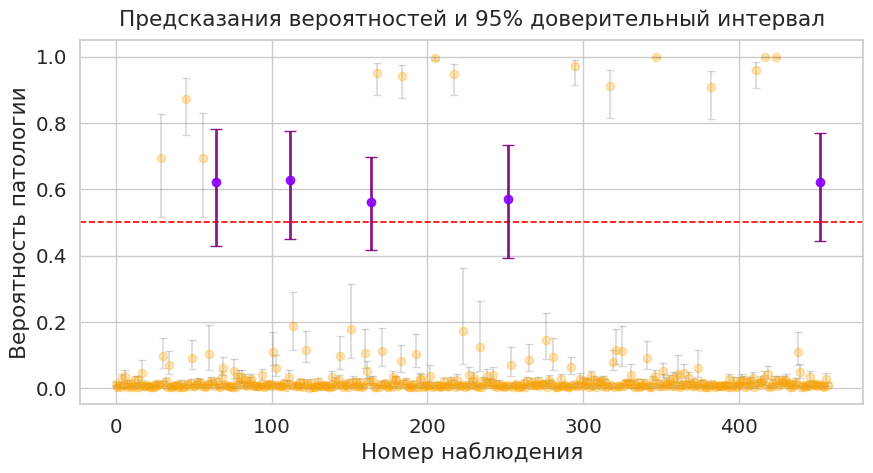

In [81]:
# вычисляем, пересекает ли доверительный интервал границу 0.5
crosses_boundary = (prediction_summary["mean_ci_lower"] <= 0.5) & (
    prediction_summary["mean_ci_upper"] >= 0.5
)
with sns.axes_style("whitegrid"):
    plt.figure(figsize=(9, 5))
    plt.axhline(0.5, color="red", linestyle="--", linewidth=1.2)

    # разбиваем на две группы
    idx_cross = np.where(crosses_boundary)[0]
    idx_no_cross = np.where(~crosses_boundary)[0]

    # интервалы, пересекающие 0.5 — яркие
    plt.errorbar(
        idx_cross,
        prediction_summary.loc[idx_cross, "mean"],
        yerr=[
            prediction_summary.loc[idx_cross, "mean"]
            - prediction_summary.loc[idx_cross, "mean_ci_lower"],
            prediction_summary.loc[idx_cross, "mean_ci_upper"]
            - prediction_summary.loc[idx_cross, "mean"],
        ],
        fmt="o",
        ecolor="purple",
        color="#8b00ff",
        elinewidth=2,
        capsize=4,
        alpha=0.9,
    )

    # интервалы, не пересекающие 0.5 — полупрозрачные
    plt.errorbar(
        idx_no_cross,
        prediction_summary.loc[idx_no_cross, "mean"],
        yerr=[
            prediction_summary.loc[idx_no_cross, "mean"]
            - prediction_summary.loc[idx_no_cross, "mean_ci_lower"],
            prediction_summary.loc[idx_no_cross, "mean_ci_upper"]
            - prediction_summary.loc[idx_no_cross, "mean"],
        ],
        fmt="o",
        ecolor="gray",
        color="orange",
        elinewidth=1.2,
        capsize=3,
        alpha=0.3,
    )

plt.ylabel("Вероятность патологии")
plt.xlabel("Номер наблюдения")
plt.title("Предсказания вероятностей и 95% доверительный интервал", pad=10)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Таким образом те точки, у которорых вероятность патологии вместе со своим доверительным интервалом ниже 0.5, здоровы с высокой точностью, их можно отпускать домой (можно поменять уровень доверия в случае опасной болезни). Те, кто строго выше, одназначно отправляются в больницу на лечение. Те, чей интервал пересекает границу оказываются под подозрением в начличии патологии, и дальше всё зависит от болезни: либо повторное тестирование с МПГ, либо тоже сразу в больницу 

**Вывод:**

При построении логистической регресси важно проверять корректность результатов и их устойчивость, аккуратно работать с мультикорреляциями и линейной зависимостью, линейностью логитов. При учёте всех требования, получается хороший интерпретируемый результат нужного уровня точности 

---
### Задача 4.


На семинаре мы рассмотрели различные подходы к калибровке классификационных моделей. Но помимо этого хочется иметь метрики калибровки для сравнения качества полученных моделей.

Сгенерируем выборку, в которой классы не являются линейно-разделимыми, а также добавим к ней фоновый шум из точек разных классов.

Используйте функцию `make_blobs`.

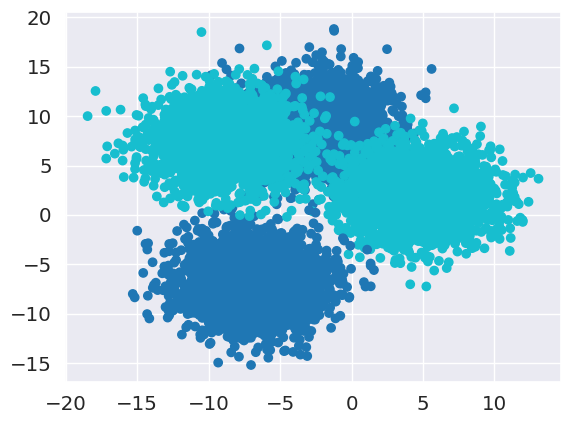

In [39]:
n_samples = 10_000
n_centers = 4
n = n_samples // n_centers

X, y_true = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_centers,
    cluster_std=2.5,
    random_state=42
)

idx = np.argsort(y_true)
X_sorted = X[idx]

y_new = np.tile([0, 1], n_centers // 2)
y_new = np.repeat(y_new, n)

plt.scatter(X_sorted[:, 0], X_sorted[:, 1], c=y_new, cmap='tab10')
plt.show()


Разделите выборку на обучение, валидацию и тест.

In [40]:
X_temp, X_test, y_temp, y_test = train_test_split(X_sorted, y_new, test_size=0.2)
X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, test_size=0.25)

Обучите любые три классификационные модели на данных, выведите их метрики.

In [41]:
knn = KNeighborsClassifier()
rf = RandomForestClassifier()
catboost = CatBoostClassifier()

knn.fit(X_train, y_train)
rf.fit(X_train, y_train)
catboost.fit(X_train, y_train)

Learning rate set to 0.022141
0:	learn: 0.6555816	total: 1.72ms	remaining: 1.71s
1:	learn: 0.6181940	total: 3.48ms	remaining: 1.74s
2:	learn: 0.5875588	total: 4.86ms	remaining: 1.61s
3:	learn: 0.5564118	total: 6.22ms	remaining: 1.55s
4:	learn: 0.5306795	total: 7.6ms	remaining: 1.51s
5:	learn: 0.5047061	total: 9.4ms	remaining: 1.56s
6:	learn: 0.4831435	total: 10.8ms	remaining: 1.53s
7:	learn: 0.4635052	total: 12.3ms	remaining: 1.52s
8:	learn: 0.4410280	total: 13.7ms	remaining: 1.5s
9:	learn: 0.4204541	total: 15ms	remaining: 1.49s
10:	learn: 0.4023773	total: 16.9ms	remaining: 1.51s
11:	learn: 0.3886864	total: 18.5ms	remaining: 1.53s
12:	learn: 0.3760855	total: 20ms	remaining: 1.52s
13:	learn: 0.3637788	total: 21.4ms	remaining: 1.51s
14:	learn: 0.3510211	total: 23.3ms	remaining: 1.53s
15:	learn: 0.3385042	total: 24.7ms	remaining: 1.52s
16:	learn: 0.3280251	total: 26.1ms	remaining: 1.51s
17:	learn: 0.3171459	total: 27.6ms	remaining: 1.5s
18:	learn: 0.3084161	total: 29.4ms	remaining: 1.52s


In [42]:
knn_pred = knn.predict(X_test)
rf_pred = rf.predict(X_test)
catboost_pred = catboost.predict(X_test)

print(f'KNN: {accuracy_score(y_test, knn_pred):.2f}')
print(f'RandomForest: {accuracy_score(y_test, rf_pred):.2f}')
print(f'CatBoost: {accuracy_score(y_test, catboost_pred):.2f}')

KNN: 0.92
RandomForest: 0.92
CatBoost: 0.93


Отрисуйте калибровочные кривые и гистограммы предсказаний данных моделей. Какие выводы можно сделать?

In [43]:
def calibration_curves(clf_list, figsize=(12, 7)):
    '''
    Отрисовка калибровочной кривой.

    clf_list -- список кортежей (обученный классификатор, его название)
    figsize -- размер фигуры
    '''

    f, ax = plt.subplots(figsize=figsize)

    for i, (clf, name) in enumerate(clf_list):
        probs = clf.predict_proba(X_test)[:, 1]
        CalibrationDisplay.from_predictions(
            y_test, probs, n_bins=20, lw=3, name=name, ax=ax, strategy='quantile'
        )
        
    ax.set_xlabel('Предсказанная вероятность (среднее внутри бина)')
    ax.set_ylabel('Доля класса 1 в бине')
    ax.set_title('Сравнение калибровочных кривых')
    plt.show();

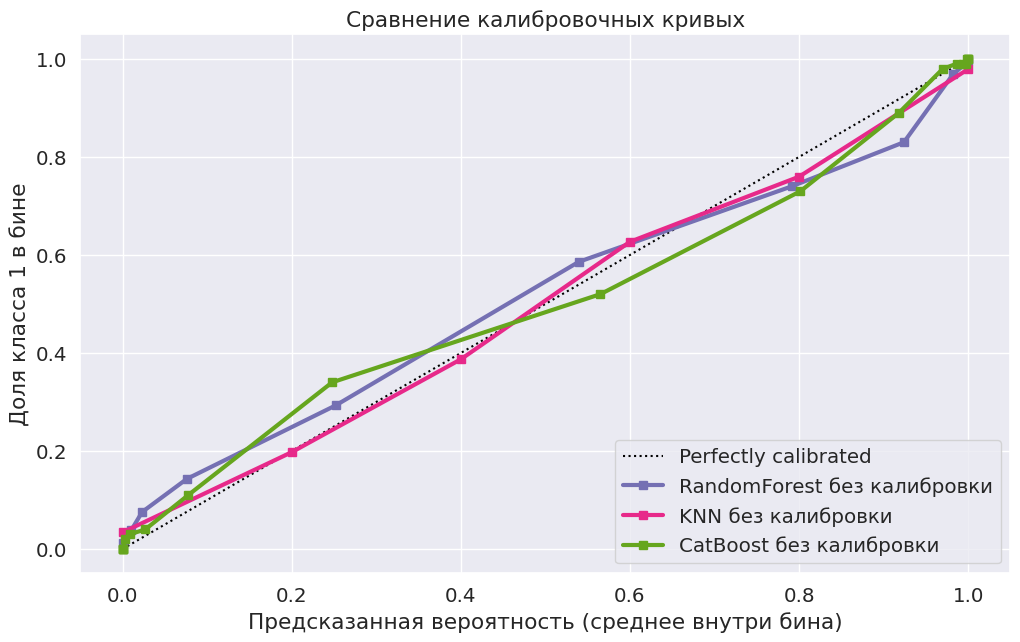

In [59]:
clf_list = [
    (rf, 'RandomForest без калибровки'),
    (knn, 'KNN без калибровки'),
    (catboost, 'CatBoost без калибровки')
]

calibration_curves(clf_list)

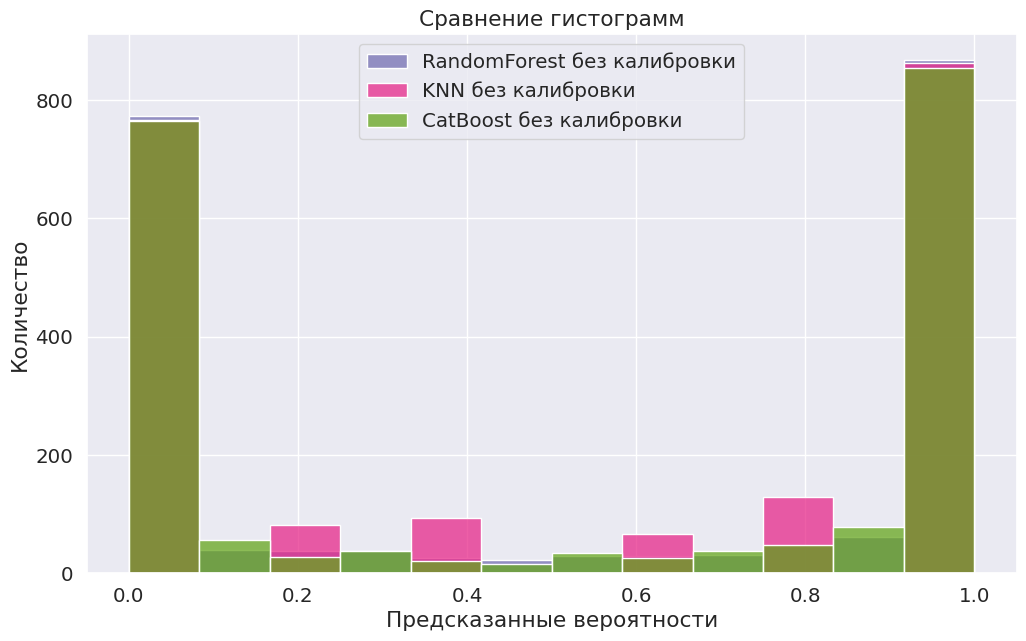

In [60]:
f, ax = plt.subplots(figsize=(12, 7))

for i, (clf, name) in enumerate(clf_list):
    probs = clf.predict_proba(X_test)[:, 1]
    sns.histplot(probs, label=name)
    
ax.set_xlabel('Предсказанные вероятности')
ax.set_ylabel('Количество')
ax.set_title('Сравнение гистограмм')
ax.legend()
plt.show();

В целом по гистограммам модели уже неплохо скалиброваны, кроме леса

Видим, что, например, CatBoost при доле класса 1 в бине 0.2 предсказывает вероятность меньше. То есть там, где он должен был дать вероятность побольше, он даёт недостаточно. А дальше наоборот, там где ему следует дать вероятность уже меньше, он выдаёт большую. Таким образом, он слишком уверенный. У KNN проблемы начинаются только около вероятности 1: сначала с неуверенностью, затем с уверенностью. Лес тоже слишком уверен

Откалибруйте модели. И посмотрите на кривые для новых моделей. Сделайте выводы.

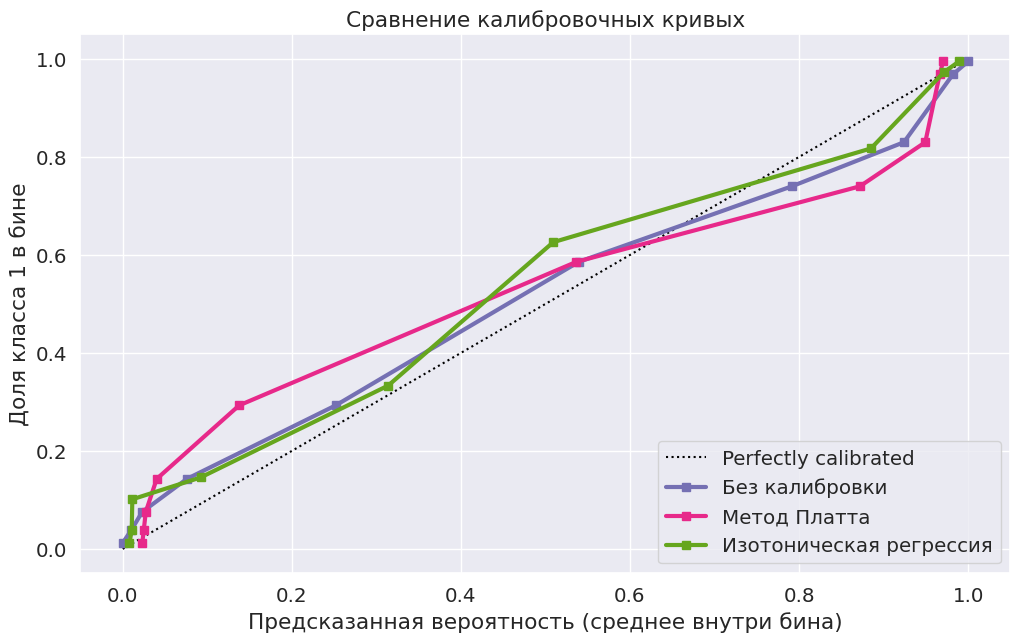

In [46]:
rf_platt = CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
rf_platt.fit(X_calib, y_calib)
y_pred_proba_platt = rf_platt.predict_proba(X_test)[:, 1]

rf_isotonic = CalibratedClassifierCV(rf, method='isotonic', cv='prefit')
rf_isotonic.fit(X_calib, y_calib)
y_pred_proba_isotonic = rf_isotonic.predict_proba(X_test)[:, 1]

clf_list = [
    (rf, 'Без калибровки'),
    (rf_platt, 'Метод Платта'),
    (rf_isotonic, 'Изотоническая регрессия')
]

calibration_curves(clf_list)

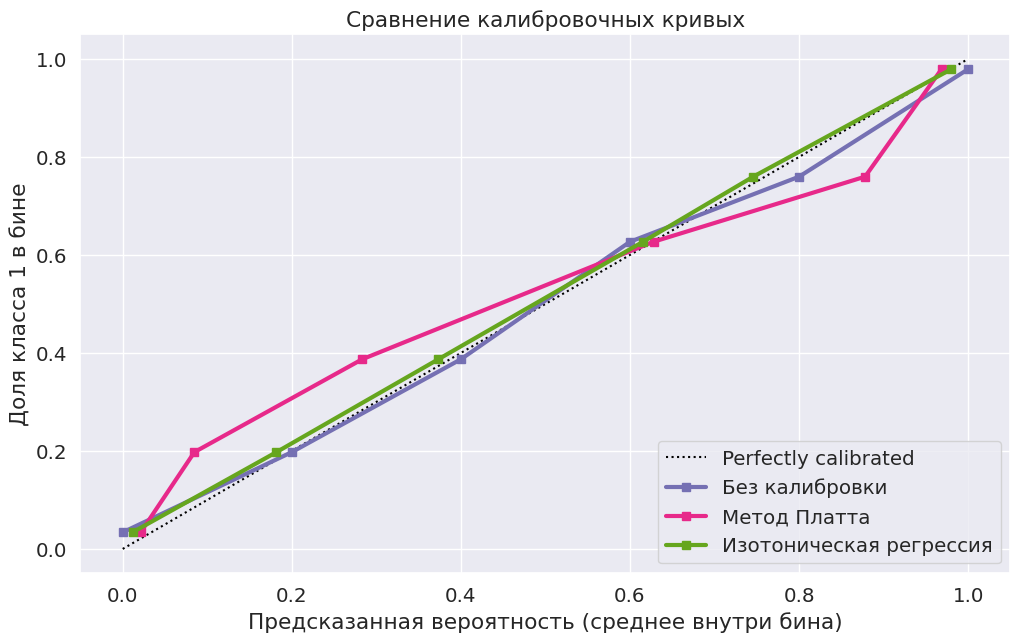

In [47]:
knn_platt = CalibratedClassifierCV(knn, method='sigmoid', cv='prefit')
knn_platt.fit(X_calib, y_calib)
y_pred_proba_platt = knn_platt.predict_proba(X_test)[:, 1]

knn_isotonic = CalibratedClassifierCV(knn, method='isotonic', cv='prefit')
knn_isotonic.fit(X_calib, y_calib)
y_pred_proba_isotonic = knn_isotonic.predict_proba(X_test)[:, 1]

clf_list = [
    (knn, 'Без калибровки'),
    (knn_platt, 'Метод Платта'),
    (knn_isotonic, 'Изотоническая регрессия')
]

calibration_curves(clf_list)

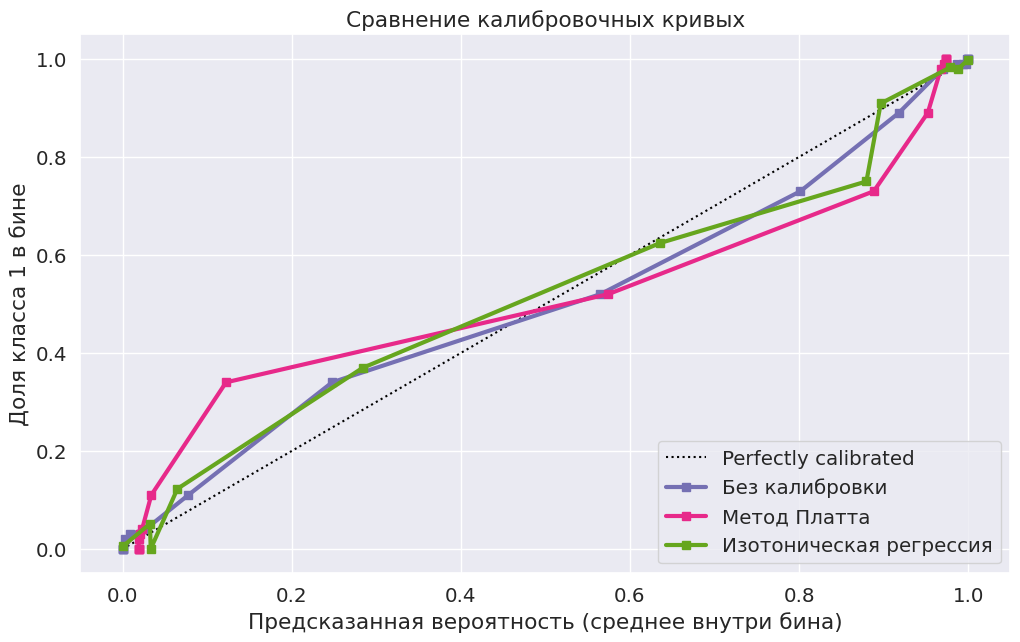

In [48]:
catboost_platt = CalibratedClassifierCV(catboost, method='sigmoid', cv='prefit')
catboost_platt.fit(X_calib, y_calib)
y_pred_proba_platt = catboost_platt.predict_proba(X_test)[:, 1]

catboost_isotonic = CalibratedClassifierCV(catboost, method='isotonic', cv='prefit')
catboost_isotonic.fit(X_calib, y_calib)
y_pred_proba_isotonic = catboost_isotonic.predict_proba(X_test)[:, 1]

clf_list = [
    (catboost, 'Без калибровки'),
    (catboost_platt, 'Метод Платта'),
    (catboost_isotonic, 'Изотоническая регрессия')
]

calibration_curves(clf_list)

Видим, что калибровка помогла, особенно хорошо сработала для KNN. Везде лучшие результаты показывается изотоническая

---

Для оценки калибровки используются, как правило, две метрики:
- Expected Callibration Error
- Brier Score

**Expected Callibration Error**

Данная метрика наследует идеи гистограммной калибровки. Пусть $B_1, \dots, B_k$ &mdash; разбиение отрезка $[0, 1]$ на непересекающиеся бины.

$$ECE = \sum_{j = 1}^k \cfrac{\sum_{i=1}^n I\{x_i \in B_j\}}{n} \left|\overline{y}(B_j) - \overline{p}(B_j)\right|$$

**Brier Score**

Данный подход ближе к изотонической регрессии.
$$BS = \sum_{i=1}^n (y_i - p(x_i))^2.$$
Причем в качестве функции разницы рассматривают не только квадратичную ошибку.

---

Реализуйте функции для подсчета метрик:

In [ ]:
<...>

Проанализируйте, какой метод калибровки лучше подоходит для каждой из моделей.

In [ ]:
<...>

**Вывод:**

<...>

---
### Задача 5.


Исследуем, насколько скалиброванны нейронные сети. Рассмотрим датасет <a href="https://www.kaggle.com/datasets/chetankv/dogs-cats-images">Dogs & Cats Images</a>. Требуется определить, кто изображен на картинке &mdash; собака или кошка.

Выделите из обучающего набора выделите трейн и валидацию в соотношении 3:1.

Постройте простую сверточную нейронную сеть для классификации изображений и обучите ее на тренировочной части данных. Используйте хотя бы несколько сверточных слоев, но слишком много не стоит.

Также выберите один из <a href="https://pytorch.org/vision/stable/models.html">видов архитектруры</a> нейронной сети для классификации изображений из torchvision, например, ResNet. Определите для него 3 варианта архитектуры с разным количеством параметров.

Для каждой рассмотренной ранее модели выполните следующие действия.
* Посмотрите на калибровочную кривую и оценку качества калибровки.
* Примените методы калибровки и сравните результаты. Посчитайте, как изменилась точность классификации на тестовой части данных.

Поясните, почему калибровку необходимо выполнять на валидационной части данных, а оценивать точность классификации &mdash; на тестовом.

Сделайте выводы.

**Вывод:**

<...>

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока